In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Options: 0 = all, 1 = filter INFO, 2 = filter WARNING, 3 = ERROR only
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth to True
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [2]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [3]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.optimizers import Adam

from IPython.display import display

In [4]:
# Custom callback to stop training after a time limit
class TimeStopping(Callback):
    def __init__(self, max_seconds=300):
        super().__init__()
        self.max_seconds = max_seconds
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        if time.time() - self.start_time > self.max_seconds:
            print(f"\n⏱️ Stopping training - time limit of {self.max_seconds} seconds reached.")
            self.model.stop_training = True

# Evaluation function
def eval_classification(model, X, y, name='model', labels=None):
    preds = np.rint(model.predict(X))
    print(classification_report(y, preds, target_names=labels))

    ConfusionMatrixDisplay.from_predictions(y, preds, display_labels=labels)
    plt.show()

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()

    score_df = pd.DataFrame(index=[name])
    score_df.loc[name, 'Accuracy'] = accuracy_score(y, preds)
    score_df.loc[name, 'Precision'] = precision_score(y, preds)
    score_df.loc[name, 'Recall'] = recall_score(y, preds)
    score_df.loc[name, 'F1 Score'] = f1_score(y, preds)
    score_df.loc[name, 'FPR'] = fp / (fp + tn)
    score_df.loc[name, 'FNR'] = fn / (fn + tp)

    return score_df

    
# Function to plot training history
def plot_history(history):
    """Takes a keras model learning history and plots each metric"""
    metrics = history.history.keys()
    for metric in metrics:
        if not 'val' in metric:
            plt.plot(history.history[f'{metric}'], label=f'{metric}')
            if f'val_{metric}' in metrics:
                plt.plot(history.history[f'val_{metric}'], label=f'val_{metric}')
            plt.legend()
            plt.title(f'{metric}')
            plt.xlabel('Epochs')
            plt.ylabel(metric.capitalize())
            plt.grid(True)
            plt.show()


### Classification:
To evaluate the model's performance, the F1 Score is used. It is suitable for phishing detection because it strikes a balance between precision and recall, considering both false positives and false negatives, rather than focusing on one aspect alone. Unlike accuracy, it treats imbalanced datasets well and prevents incorrect performance conclusions. By encapsulating both types of error within a single metric, F1 provides a better understanding of the model's performance and confidence.

### Pseudo Code

FOR each layer_config in layer_configs:
  FOR each epoch_count in epochs_list:
    FOR each min_delta in min_deltas:
      FOR each patience_value in patiences:
        Build sequential model
        Add input + hidden layers with relu
        Add sigmoid output layer
        Compile with Adam, binary_crossentropy
        Apply EarlyStopping + TimeStopping
        Train on X_train, validate on X_val
        Evaluate on both sets using F1 Score, Accuracy, Precision, Recall
        If best F1, save model and config


In [5]:
df_train = pd.read_csv('Split_Data/Model_Ready/train.csv')
df_train.head()
# Define X and y and train data
X_train = df_train.drop(columns = 'label')
y_train = df_train['label']

df_val = pd.read_csv('Split_Data/Model_Ready/val.csv')

# Define X and y and train data
X_val = df_val.drop(columns = 'label')
y_val = df_val['label']

### Build de Model

In [6]:
# ---------------------------------------------------------
# Define hyperparameter search space for grid search
# ---------------------------------------------------------

# Each entry in `layer_configs` is a list representing the number of neurons in each hidden layer
layer_configs = [[64], [128, 64], [256, 128, 64]]

# Number of epochs (maximum) to allow during training
epochs_list = [50, 100]

# Minimum change in validation loss to qualify as an improvement
# Used by the EarlyStopping callback to determine convergence
min_deltas = [0.0, 0.001]

# Number of epochs to wait after no improvement before stopping early
patiences = [1, 3, 5]

# ---------------------------------------------------------
# Initialize tracking variables to record the best model run
# ---------------------------------------------------------

# Collect all evaluation metrics (train/val scores) across all configurations
all_scores = []

# Best F1 score seen so far (used to determine the top-performing model)
best_f1 = -1

# Store the best Keras model instance
best_model = None

# Store the training history of the best model (for plotting)
best_history = None

# Store the hyperparameter configuration of the best model
best_config = None



Config: layers=[64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1752876116.173411  469682 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1752876116.173436  469682 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


1650/1650 - 9s - 5ms/step - accuracy: 0.9488 - loss: 0.1444 - val_accuracy: 0.9557 - val_loss: 0.1333
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9560 - loss: 0.1274 - val_accuracy: 0.9548 - val_loss: 0.1281
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9558 - loss: 0.1269 - val_accuracy: 0.9588 - val_loss: 0.1213
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9551 - loss: 0.1285 - val_accuracy: 0.9575 - val_loss: 0.1218
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.1213, stopped at epoch 4

Print History


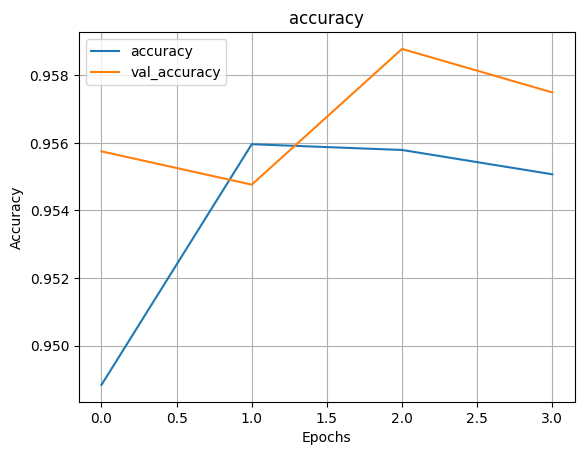

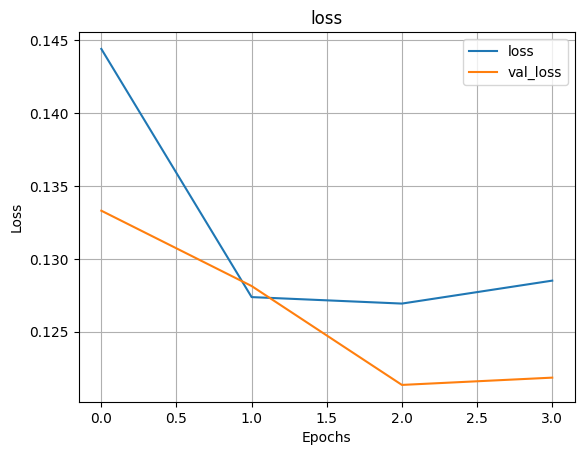

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 640us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



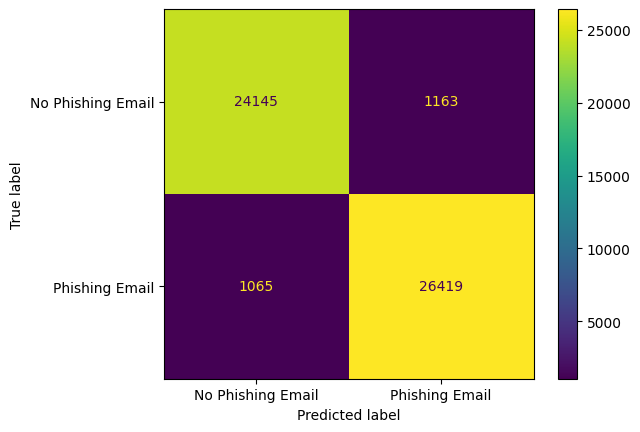

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



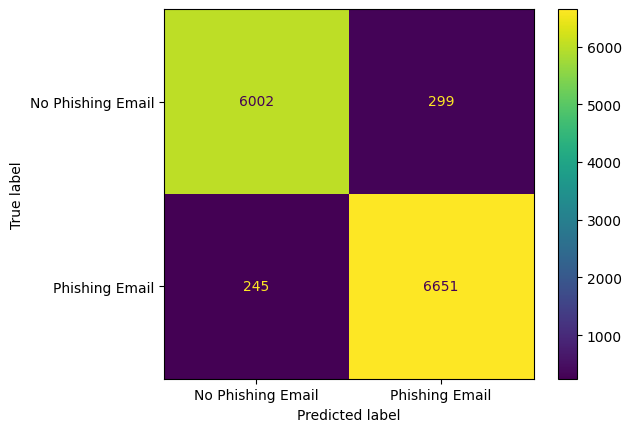


Config: layers=[64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9501 - loss: 0.1399 - val_accuracy: 0.9548 - val_loss: 0.1275
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1251 - val_accuracy: 0.9552 - val_loss: 0.1250
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1256 - val_accuracy: 0.9600 - val_loss: 0.1183
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9563 - loss: 0.1251 - val_accuracy: 0.9553 - val_loss: 0.1293
Epoch 5/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9558 - loss: 0.1263 - val_accuracy: 0.9568 - val_loss: 0.1243
Epoch 6/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9555 - loss: 0.1302 - val_accuracy: 0.9558 - val_loss: 0.1287
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.1183, stopped at epoch 6

Print History


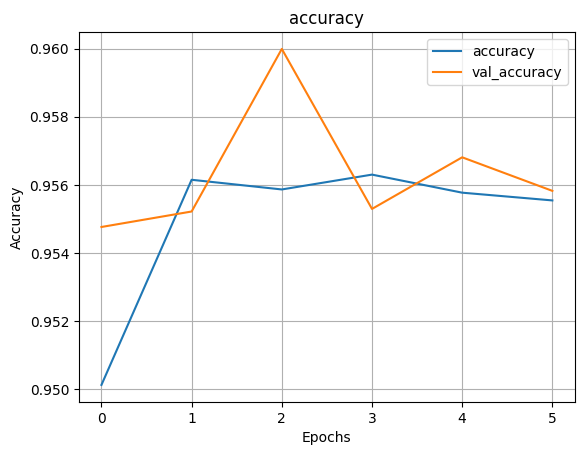

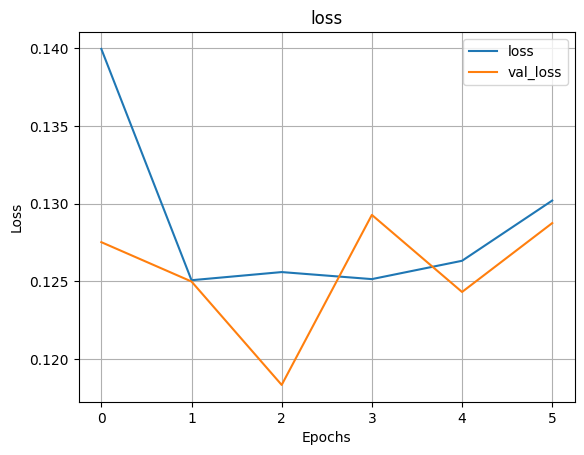

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 639us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



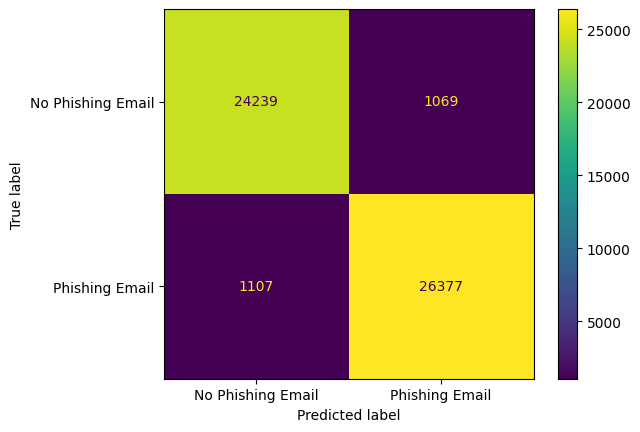

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



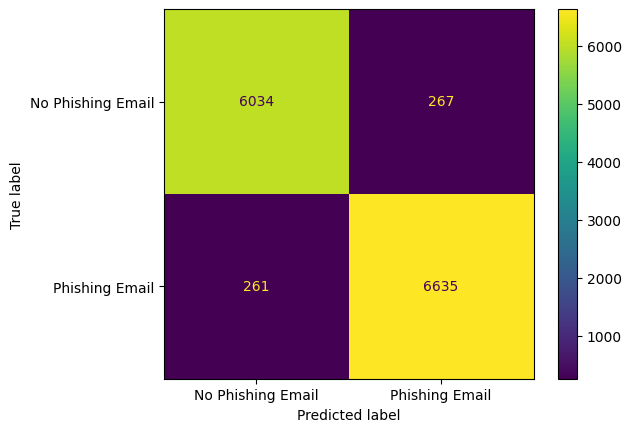


Config: layers=[64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9472 - loss: 0.1445 - val_accuracy: 0.9573 - val_loss: 0.1215
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9554 - loss: 0.1277 - val_accuracy: 0.9583 - val_loss: 0.1236
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9555 - loss: 0.1266 - val_accuracy: 0.9575 - val_loss: 0.1218
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9564 - loss: 0.1256 - val_accuracy: 0.9579 - val_loss: 0.1209
Epoch 5/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9553 - loss: 0.1284 - val_accuracy: 0.9556 - val_loss: 0.1263
Epoch 6/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9555 - loss: 0.1299 - val_accuracy: 0.9592 - val_loss: 0.1222
Epoch 7/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9542 - loss: 0.1284 - val_accuracy: 0.9510 - val_loss: 0.1420
Epoch 8/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9547 - loss: 0.1315 - val_accuracy: 0.9565 - val_loss: 0.1228
Epoch 9/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9555 - loss: 0.1304 - val_accuracy: 0.9585 - val_loss: 0

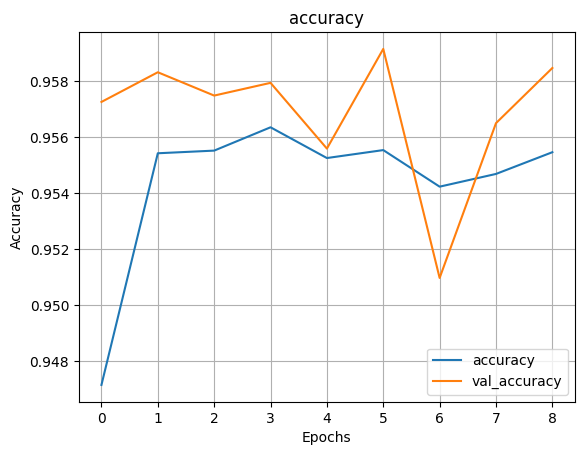

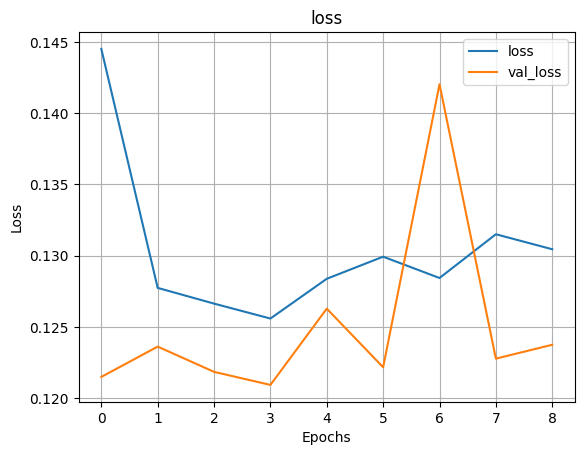

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 633us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



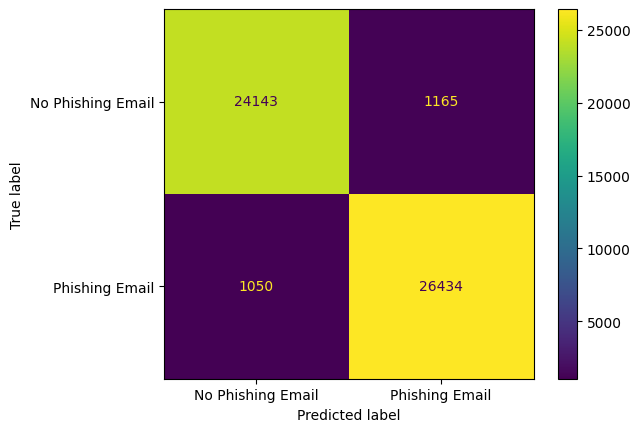

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



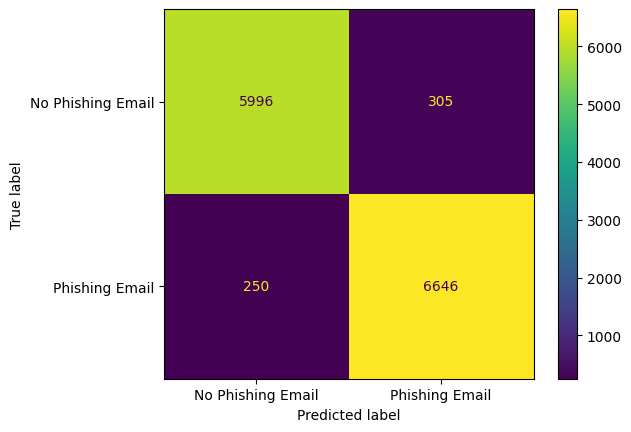


Config: layers=[64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9488 - loss: 0.1438 - val_accuracy: 0.9564 - val_loss: 0.1259
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9565 - loss: 0.1244 - val_accuracy: 0.9570 - val_loss: 0.1202
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9570 - loss: 0.1234 - val_accuracy: 0.9574 - val_loss: 0.1248
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.1202, stopped at epoch 3

Print History


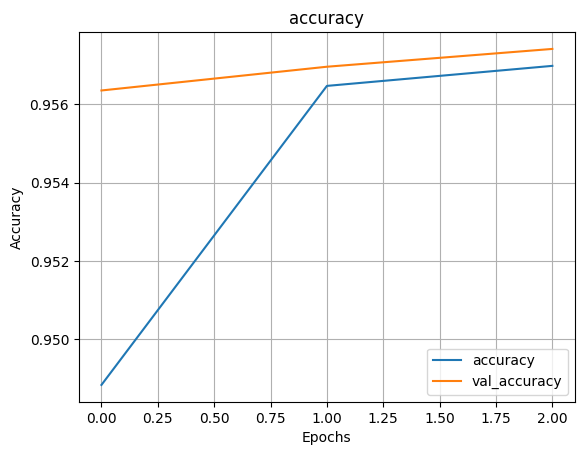

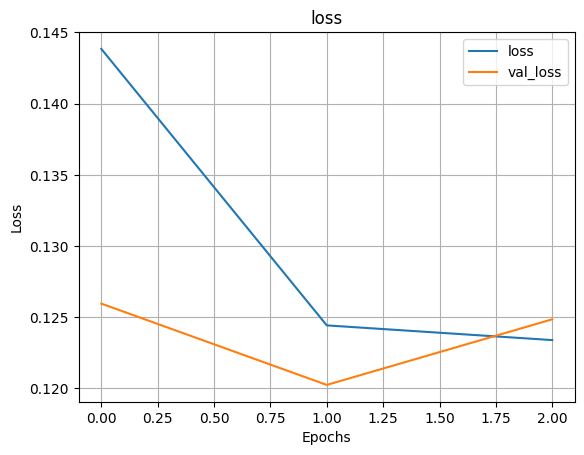

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 634us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.95     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



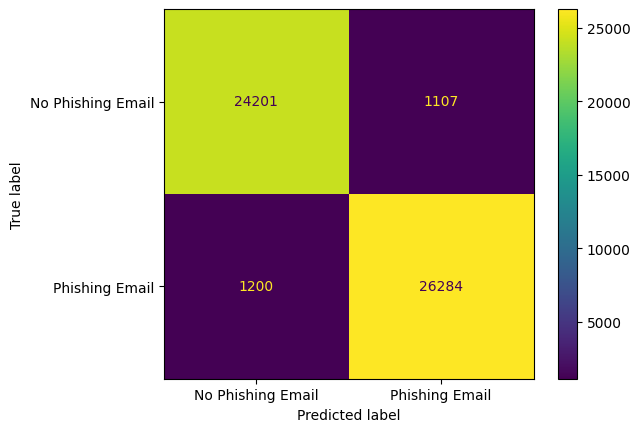

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.95      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



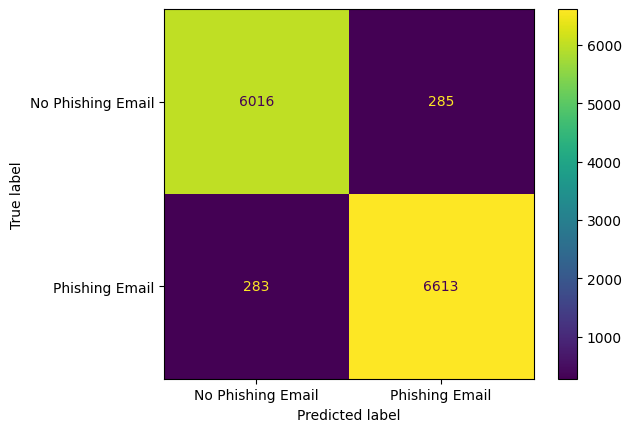


Config: layers=[64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9499 - loss: 0.1446 - val_accuracy: 0.9548 - val_loss: 0.1291
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9546 - loss: 0.1259 - val_accuracy: 0.9514 - val_loss: 0.1345
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9557 - loss: 0.1258 - val_accuracy: 0.9601 - val_loss: 0.1178
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9554 - loss: 0.1262 - val_accuracy: 0.9576 - val_loss: 0.1250
Epoch 5/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1292 - val_accuracy: 0.9555 - val_loss: 0.1290
Epoch 6/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9549 - loss: 0.1283 - val_accuracy: 0.9576 - val_loss: 0.1247
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.1178, stopped at epoch 6

Print History


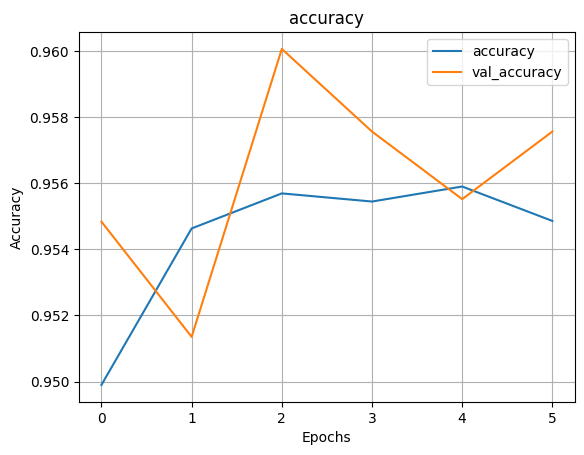

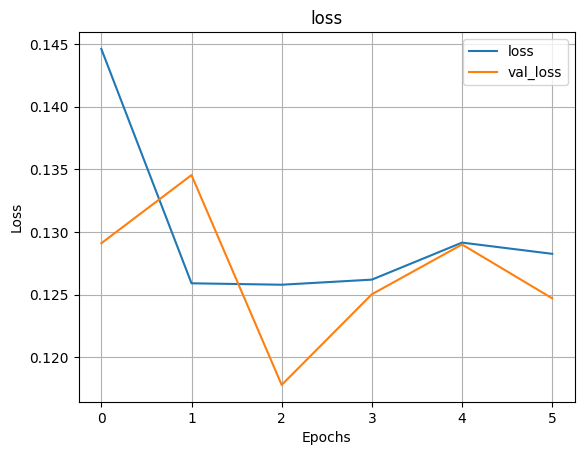

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 635us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96     25308
   Phishing Email       0.96      0.97      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



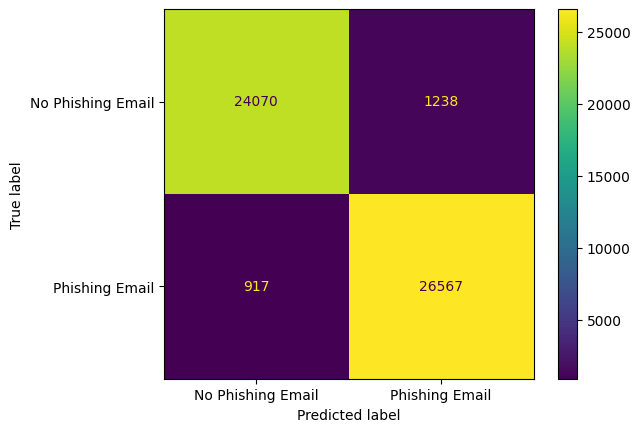

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step
                   precision    recall  f1-score   support

No Phishing Email       0.97      0.95      0.96      6301
   Phishing Email       0.95      0.97      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



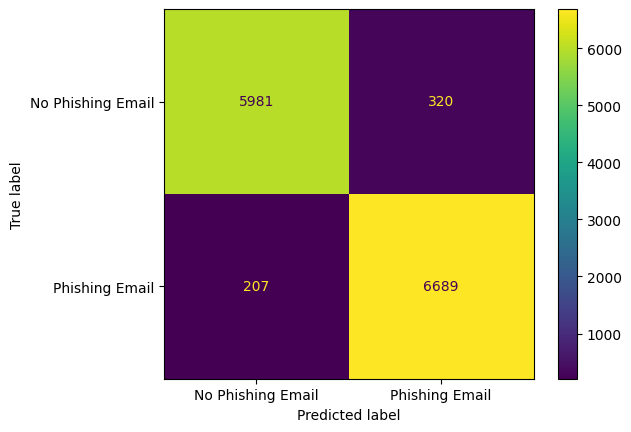


Config: layers=[64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9482 - loss: 0.1489 - val_accuracy: 0.9562 - val_loss: 0.1246
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9554 - loss: 0.1251 - val_accuracy: 0.9560 - val_loss: 0.1240
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1249 - val_accuracy: 0.9600 - val_loss: 0.1176
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9552 - loss: 0.1249 - val_accuracy: 0.9522 - val_loss: 0.1515
Epoch 5/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1254 - val_accuracy: 0.9586 - val_loss: 0.1207
Epoch 6/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9556 - loss: 0.1254 - val_accuracy: 0.9586 - val_loss: 0.1215
Epoch 7/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1254 - val_accuracy: 0.9594 - val_loss: 0.1208
Epoch 8/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9554 - loss: 0.1269 - val_accuracy: 0.9517 - val_loss: 0.1344
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=

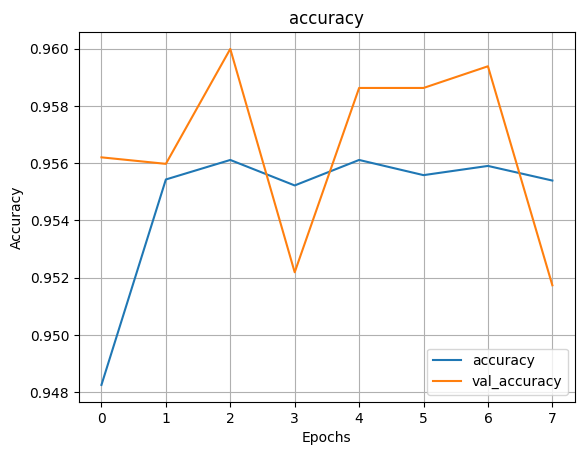

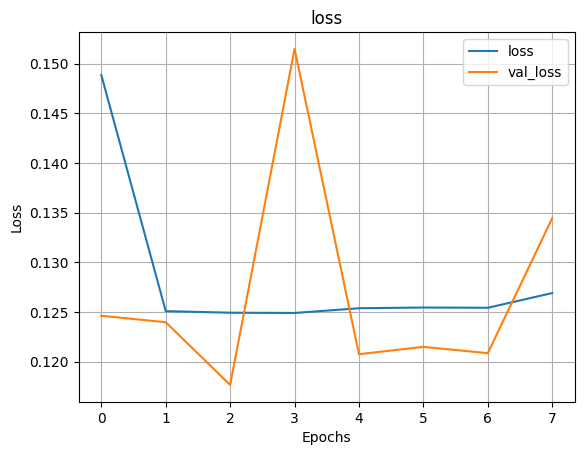

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 635us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



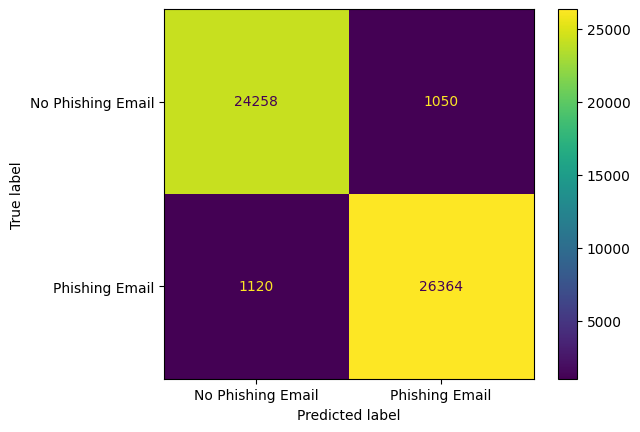

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



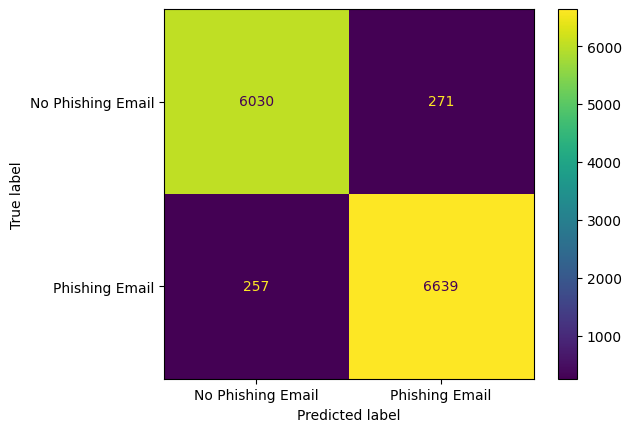


Config: layers=[64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9490 - loss: 0.1460 - val_accuracy: 0.9581 - val_loss: 0.1253
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9552 - loss: 0.1267 - val_accuracy: 0.9570 - val_loss: 0.1261
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1253, stopped at epoch 2

Print History


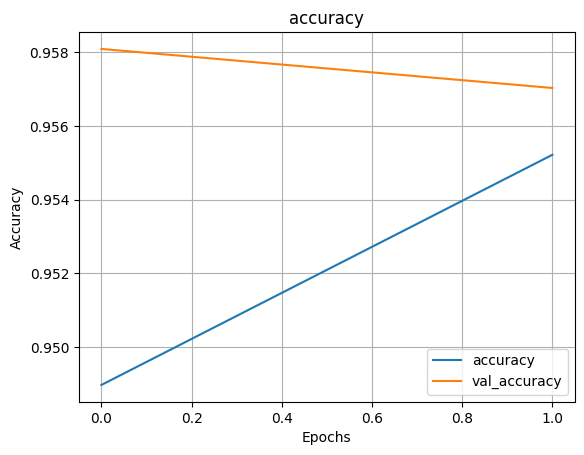

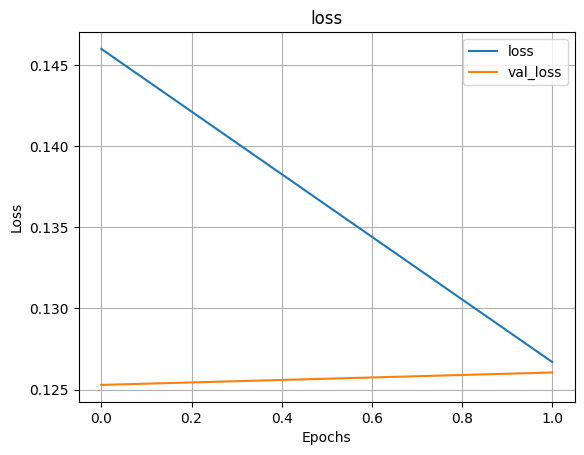

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 619us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.95     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



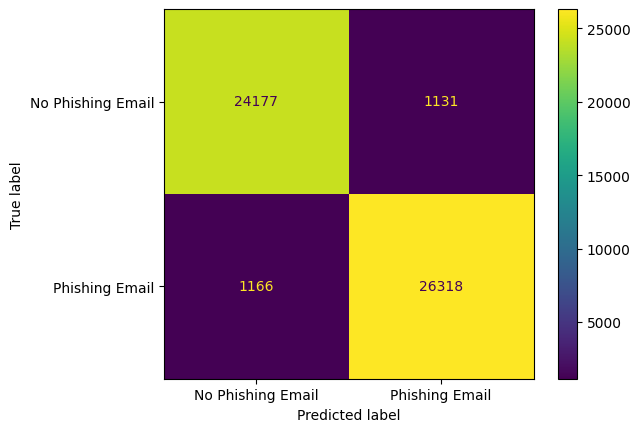

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



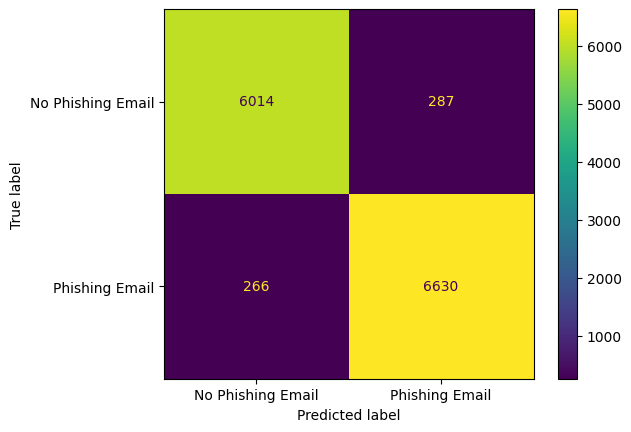


Config: layers=[64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9480 - loss: 0.1454 - val_accuracy: 0.9565 - val_loss: 0.1264
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9550 - loss: 0.1257 - val_accuracy: 0.9579 - val_loss: 0.1232
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1249 - val_accuracy: 0.9589 - val_loss: 0.1228
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1255 - val_accuracy: 0.9549 - val_loss: 0.1272
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9553 - loss: 0.1285 - val_accuracy: 0.9571 - val_loss: 0.1322
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1280 - val_accuracy: 0.9567 - val_loss: 0.1331
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.1228, stopped at epoch 6

Print History


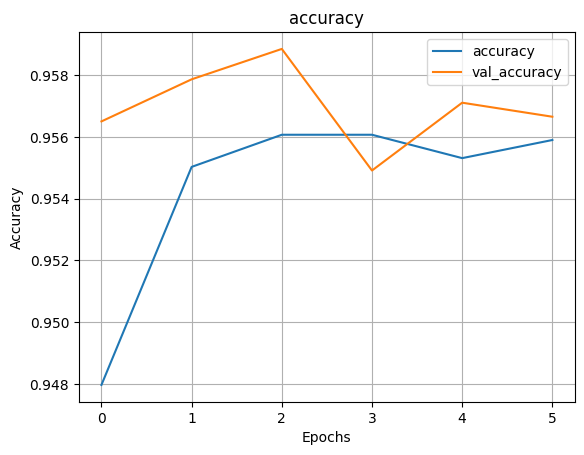

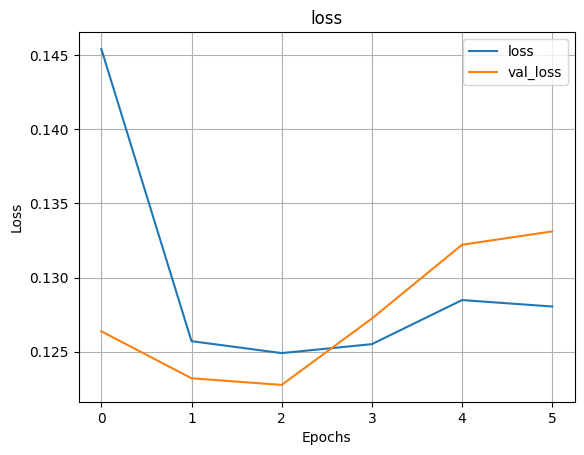

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 620us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



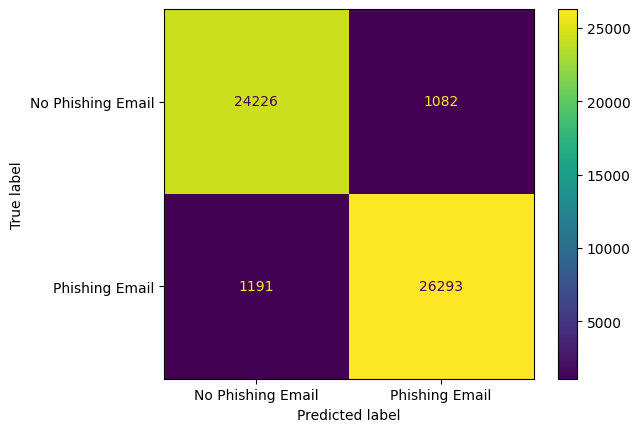

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



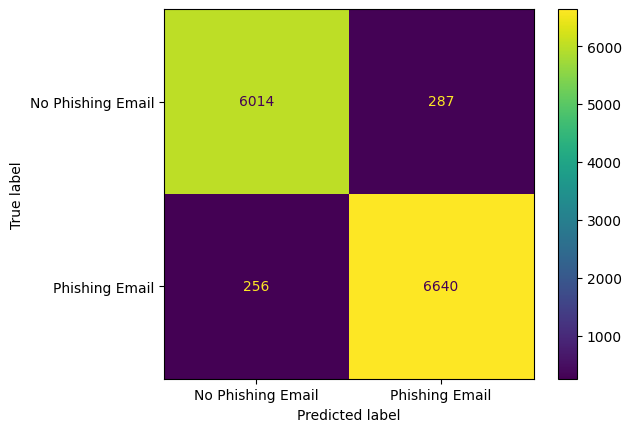


Config: layers=[64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9464 - loss: 0.1527 - val_accuracy: 0.9581 - val_loss: 0.1225
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9548 - loss: 0.1292 - val_accuracy: 0.9582 - val_loss: 0.1205
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1263 - val_accuracy: 0.9570 - val_loss: 0.1227
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9560 - loss: 0.1268 - val_accuracy: 0.9564 - val_loss: 0.1262
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9548 - loss: 0.1288 - val_accuracy: 0.9539 - val_loss: 0.1273
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9552 - loss: 0.1298 - val_accuracy: 0.9548 - val_loss: 0.1344
Epoch 7/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9545 - loss: 0.1313 - val_accuracy: 0.9606 - val_loss: 0.1206
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.1205, stopped at epoch 7

Print History


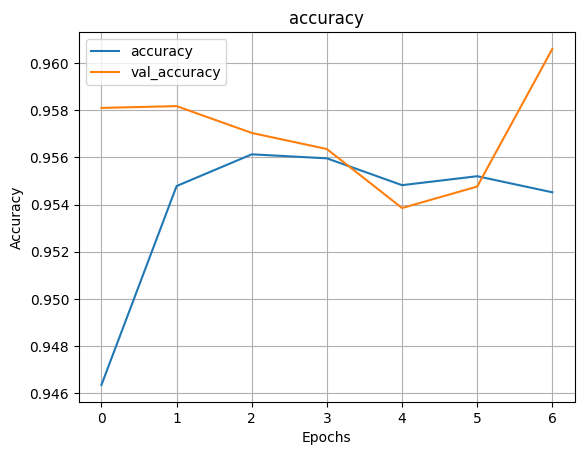

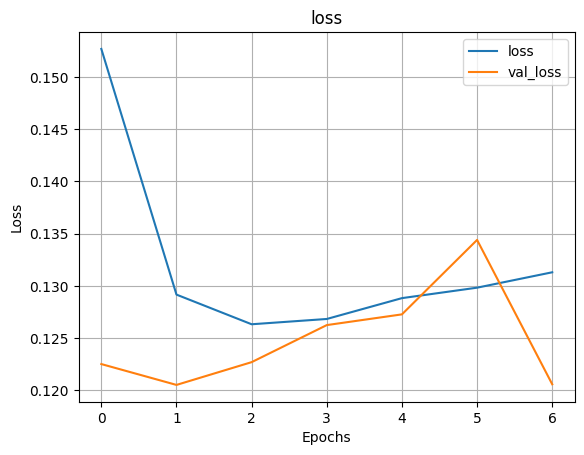

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 644us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



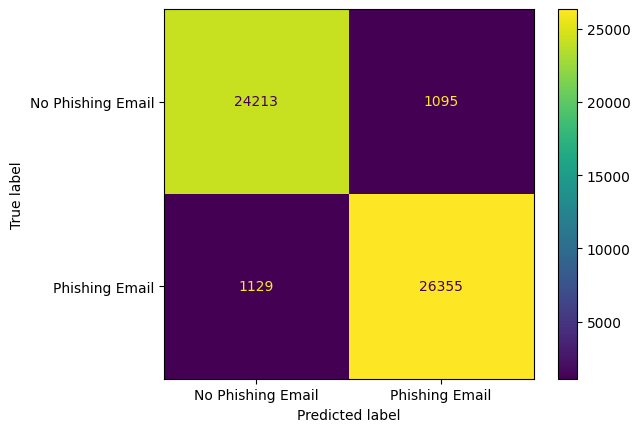

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



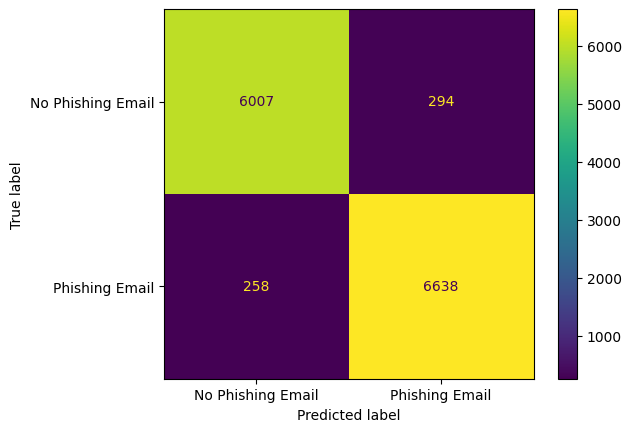


Config: layers=[64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9496 - loss: 0.1409 - val_accuracy: 0.9579 - val_loss: 0.1196
Epoch 2/100
1650/1650 - 9s - 5ms/step - accuracy: 0.9565 - loss: 0.1250 - val_accuracy: 0.9572 - val_loss: 0.1214
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1196, stopped at epoch 2

Print History


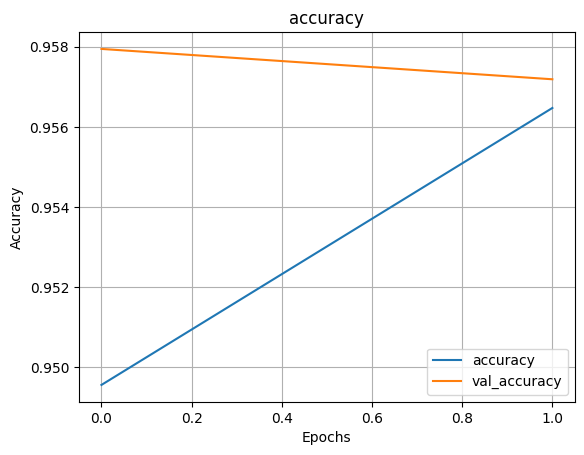

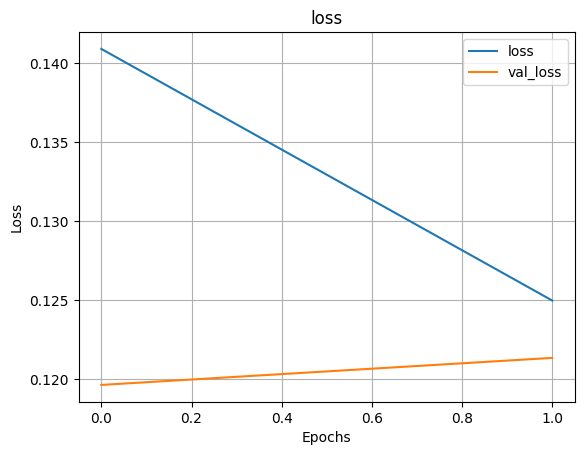

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 645us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



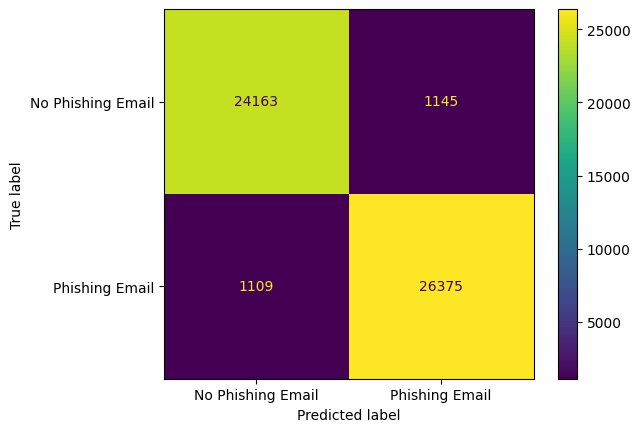

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



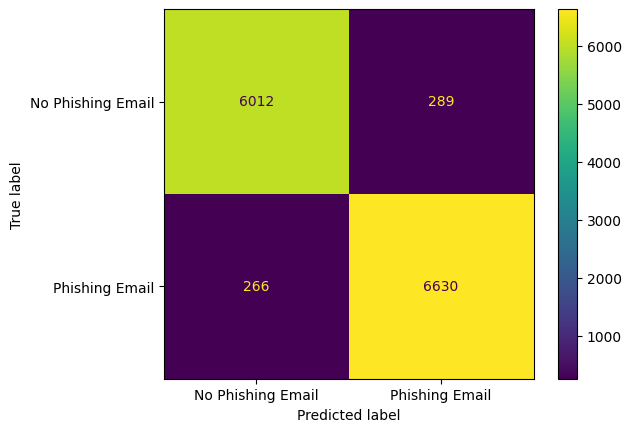


Config: layers=[64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9477 - loss: 0.1485 - val_accuracy: 0.9581 - val_loss: 0.1231
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9551 - loss: 0.1262 - val_accuracy: 0.9567 - val_loss: 0.1249
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1259 - val_accuracy: 0.9586 - val_loss: 0.1178
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9560 - loss: 0.1251 - val_accuracy: 0.9589 - val_loss: 0.1244
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9552 - loss: 0.1264 - val_accuracy: 0.9568 - val_loss: 0.1273
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1244 - val_accuracy: 0.9583 - val_loss: 0.1228
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.1178, stopped at epoch 6

Print History


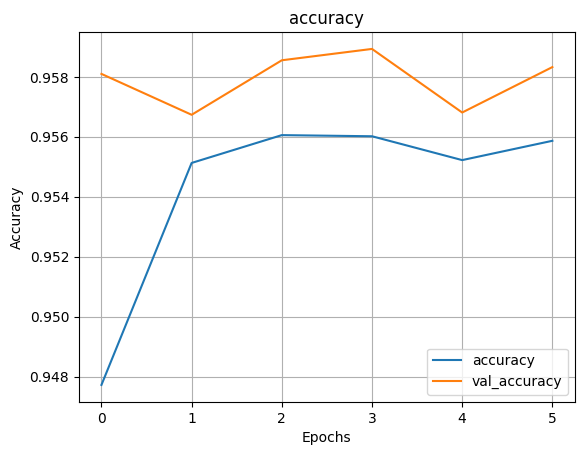

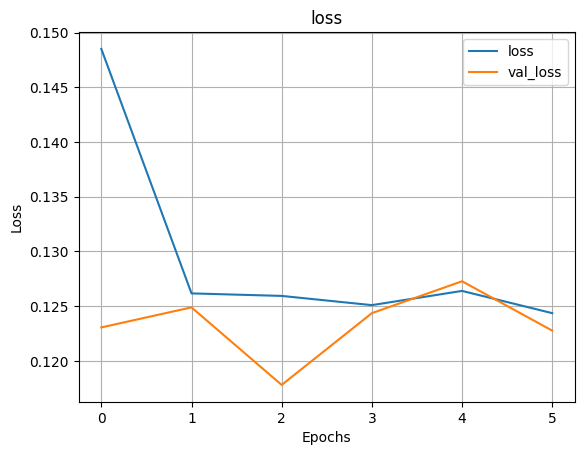

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 633us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



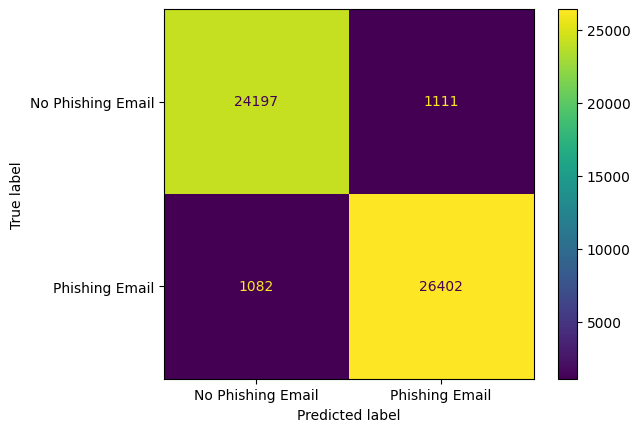

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



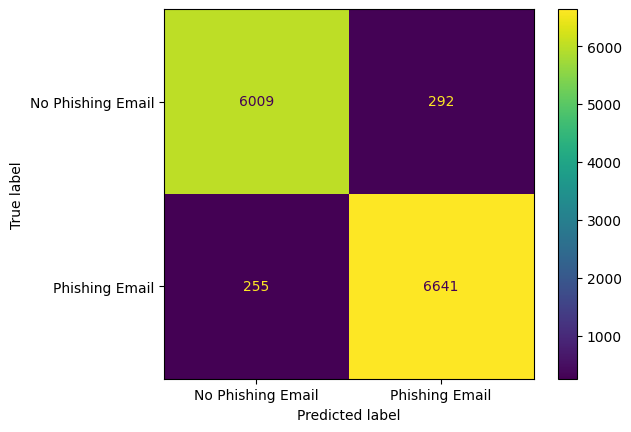


Config: layers=[64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9491 - loss: 0.1423 - val_accuracy: 0.9576 - val_loss: 0.1224
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1252 - val_accuracy: 0.9566 - val_loss: 0.1190
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1245 - val_accuracy: 0.9570 - val_loss: 0.1214
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9565 - loss: 0.1249 - val_accuracy: 0.9586 - val_loss: 0.1223
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9562 - loss: 0.1251 - val_accuracy: 0.9594 - val_loss: 0.1183
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9558 - loss: 0.1276 - val_accuracy: 0.9564 - val_loss: 0.1249
Epoch 7/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9563 - loss: 0.1265 - val_accuracy: 0.9573 - val_loss: 0.1189
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.1183, stopped at epoch 7

Print History


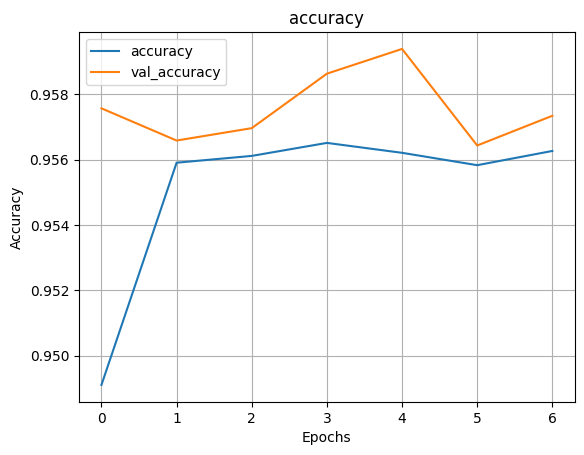

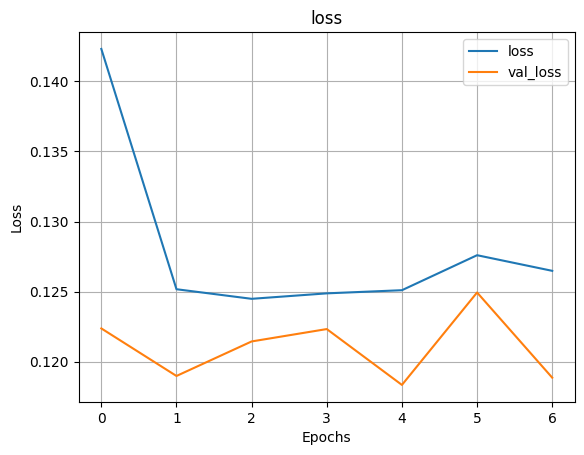

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 635us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



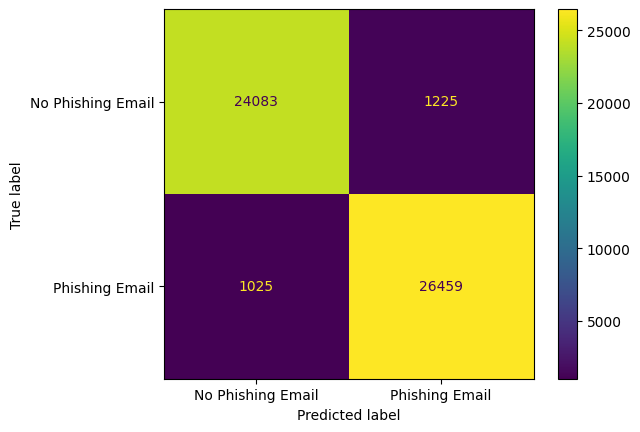

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.95      6301
   Phishing Email       0.95      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



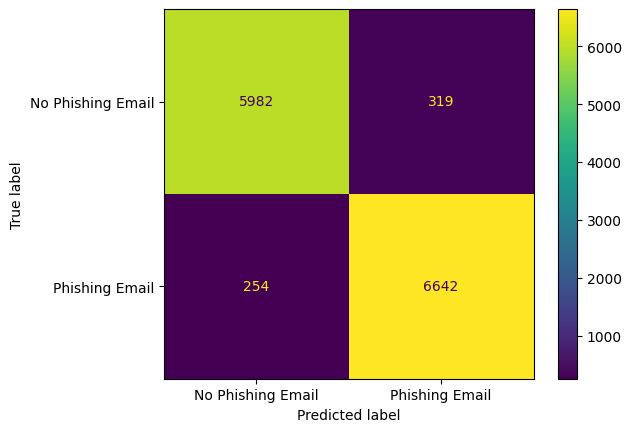


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9416 - loss: 0.1817 - val_accuracy: 0.9135 - val_loss: 0.3458
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9294 - loss: 0.4425 - val_accuracy: 0.9141 - val_loss: 0.8630
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.3458, stopped at epoch 2

Print History


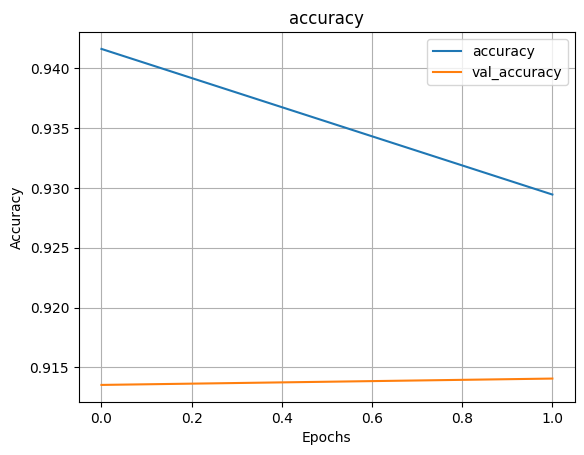

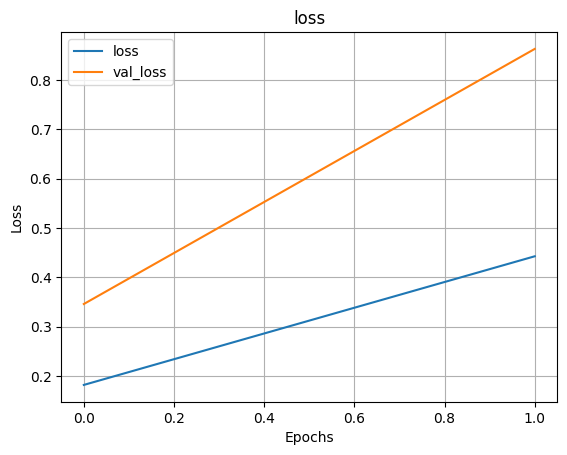

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 661us/step
                   precision    recall  f1-score   support

No Phishing Email       0.91      0.91      0.91     25308
   Phishing Email       0.92      0.92      0.92     27484

         accuracy                           0.91     52792
        macro avg       0.91      0.91      0.91     52792
     weighted avg       0.91      0.91      0.91     52792



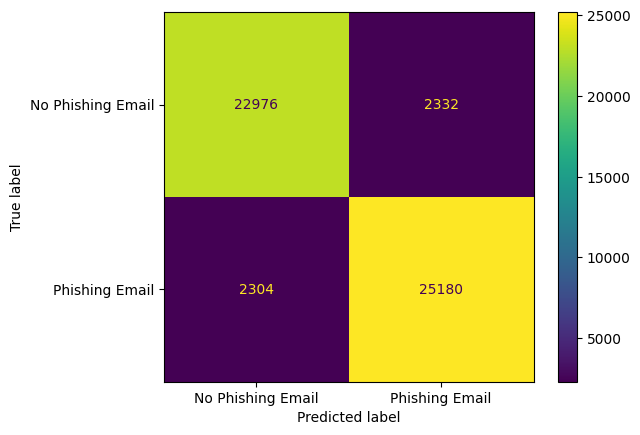

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step
                   precision    recall  f1-score   support

No Phishing Email       0.91      0.91      0.91      6301
   Phishing Email       0.92      0.92      0.92      6896

         accuracy                           0.91     13197
        macro avg       0.91      0.91      0.91     13197
     weighted avg       0.91      0.91      0.91     13197



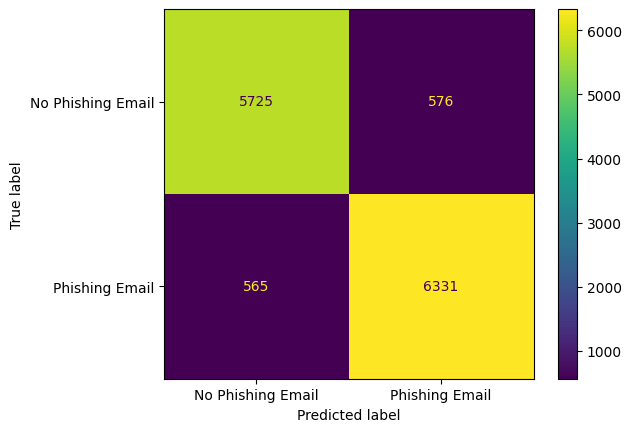


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9437 - loss: 0.1742 - val_accuracy: 0.9313 - val_loss: 0.2731
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9344 - loss: 0.3159 - val_accuracy: 0.9271 - val_loss: 0.4017
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9267 - loss: 0.6876 - val_accuracy: 0.9417 - val_loss: 0.6524
Epoch 4/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9255 - loss: 1.3336 - val_accuracy: 0.9389 - val_loss: 1.0822
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.2731, stopped at epoch 4

Print History


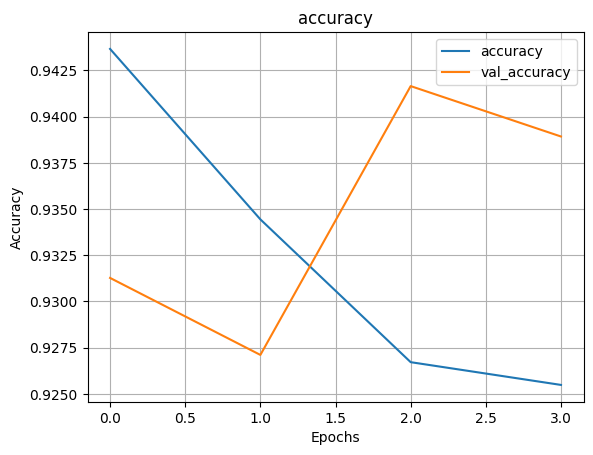

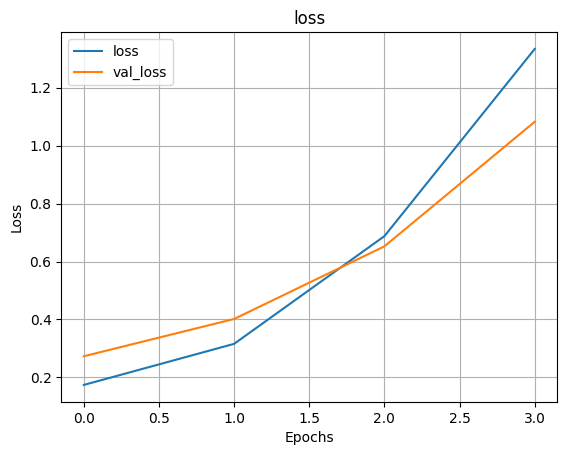

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 665us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.94      0.93     25308
   Phishing Email       0.94      0.93      0.94     27484

         accuracy                           0.93     52792
        macro avg       0.93      0.93      0.93     52792
     weighted avg       0.93      0.93      0.93     52792



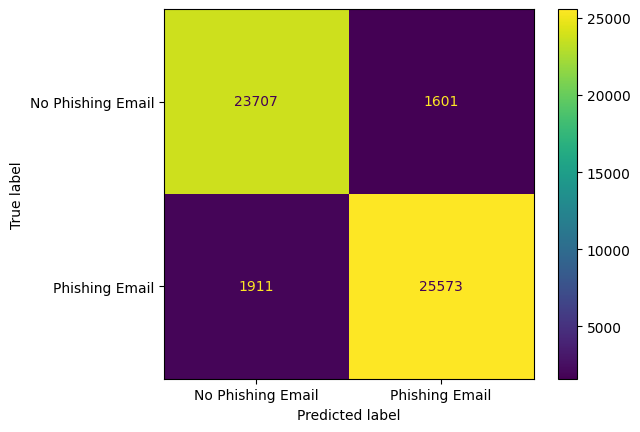

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.93      0.93      6301
   Phishing Email       0.94      0.93      0.93      6896

         accuracy                           0.93     13197
        macro avg       0.93      0.93      0.93     13197
     weighted avg       0.93      0.93      0.93     13197



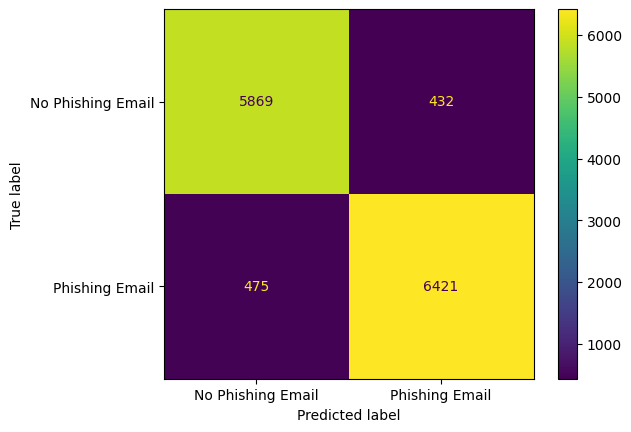


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9415 - loss: 0.1763 - val_accuracy: 0.9457 - val_loss: 0.1800
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9320 - loss: 0.3119 - val_accuracy: 0.9433 - val_loss: 0.3270
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9266 - loss: 0.6978 - val_accuracy: 0.9313 - val_loss: 0.8439
Epoch 4/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9235 - loss: 1.3656 - val_accuracy: 0.9505 - val_loss: 0.8941
Epoch 5/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9314 - loss: 1.8280 - val_accuracy: 0.8818 - val_loss: 4.2353
Epoch 6/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9281 - loss: 2.2090 - val_accuracy: 0.9354 - val_loss: 2.2593
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1800, stopped at epoch 6

Print History


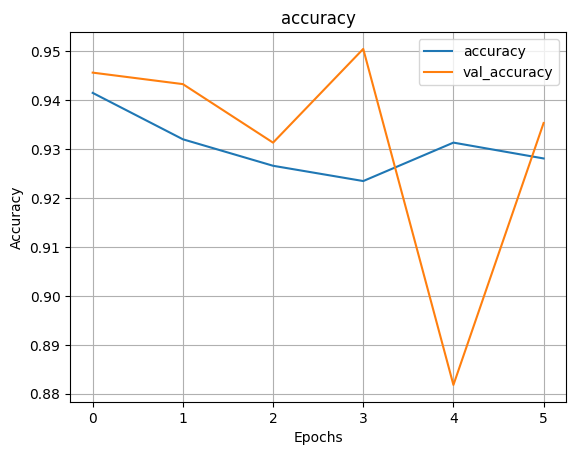

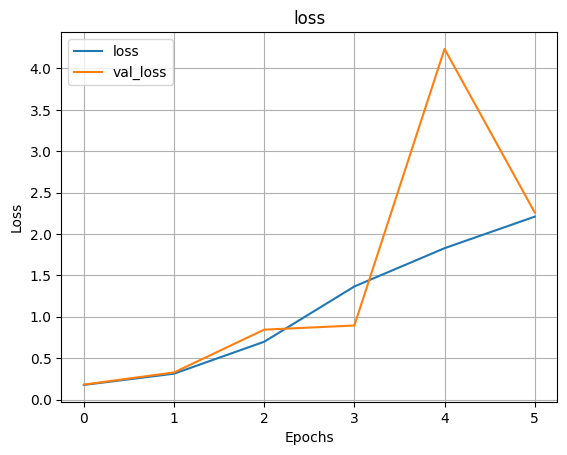

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 657us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.95      0.94     25308
   Phishing Email       0.95      0.94      0.95     27484

         accuracy                           0.94     52792
        macro avg       0.94      0.94      0.94     52792
     weighted avg       0.94      0.94      0.94     52792



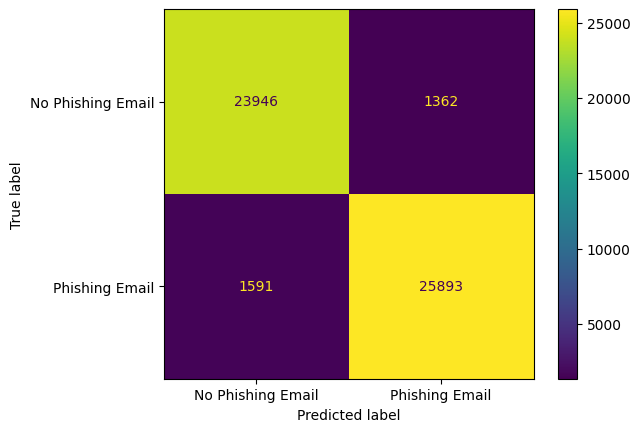

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.95      0.94      6301
   Phishing Email       0.95      0.94      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



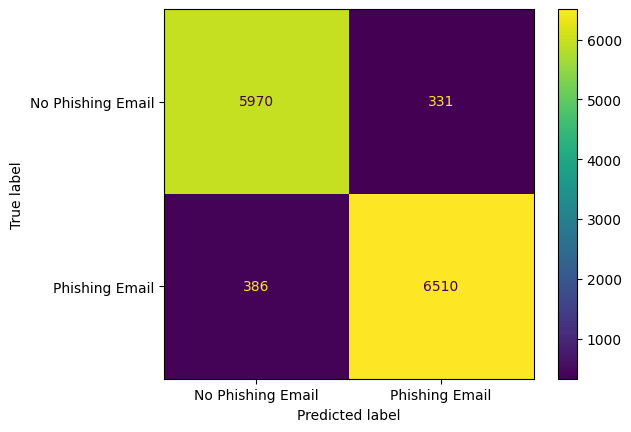


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9412 - loss: 0.1834 - val_accuracy: 0.9301 - val_loss: 0.3034
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9281 - loss: 0.4491 - val_accuracy: 0.9176 - val_loss: 0.7501
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.3034, stopped at epoch 2

Print History


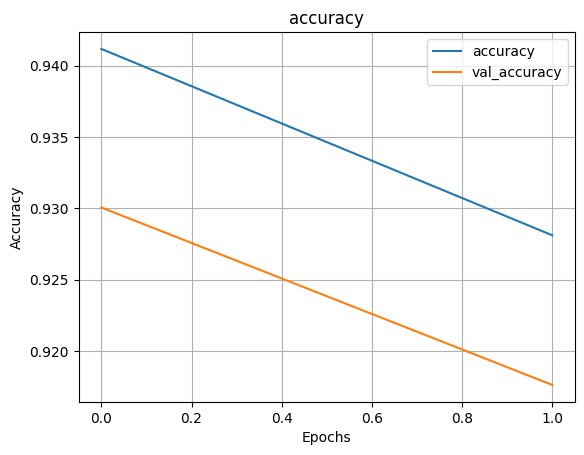

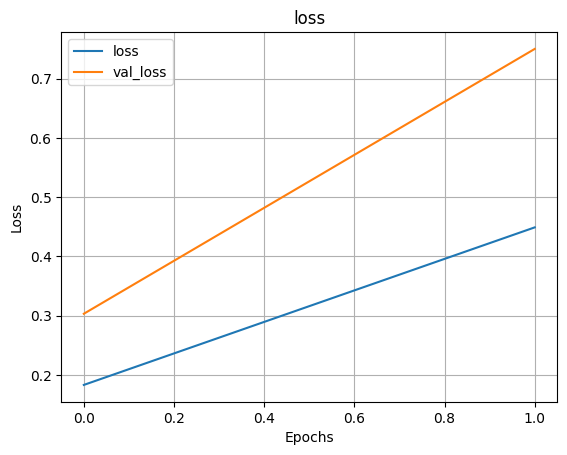

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.94      0.93     25308
   Phishing Email       0.94      0.92      0.93     27484

         accuracy                           0.93     52792
        macro avg       0.93      0.93      0.93     52792
     weighted avg       0.93      0.93      0.93     52792



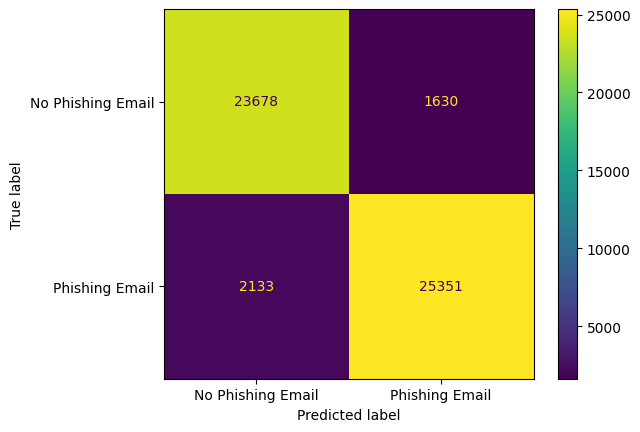

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.93      0.93      6301
   Phishing Email       0.94      0.93      0.93      6896

         accuracy                           0.93     13197
        macro avg       0.93      0.93      0.93     13197
     weighted avg       0.93      0.93      0.93     13197



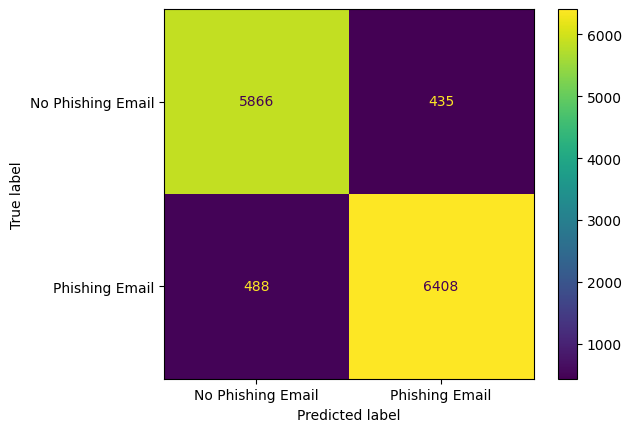


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9417 - loss: 0.1824 - val_accuracy: 0.9320 - val_loss: 0.4771
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9260 - loss: 0.5376 - val_accuracy: 0.7454 - val_loss: 4.4261
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9254 - loss: 1.3373 - val_accuracy: 0.9528 - val_loss: 0.8445
Epoch 4/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9260 - loss: 2.2962 - val_accuracy: 0.9491 - val_loss: 1.4096
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.4771, stopped at epoch 4

Print History


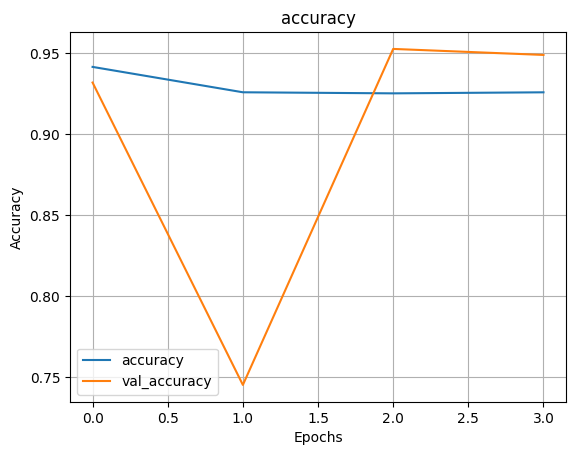

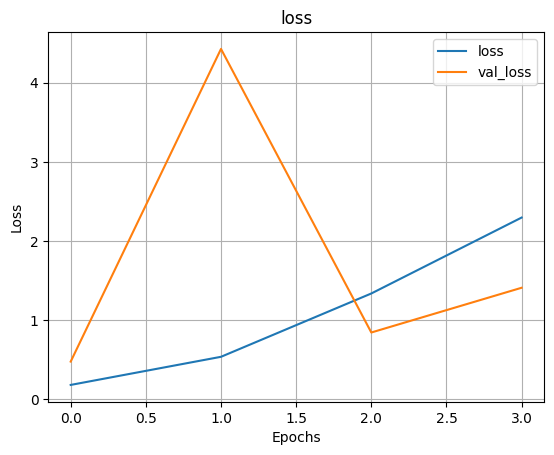

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.90      0.93     25308
   Phishing Email       0.92      0.96      0.94     27484

         accuracy                           0.93     52792
        macro avg       0.94      0.93      0.93     52792
     weighted avg       0.94      0.93      0.93     52792



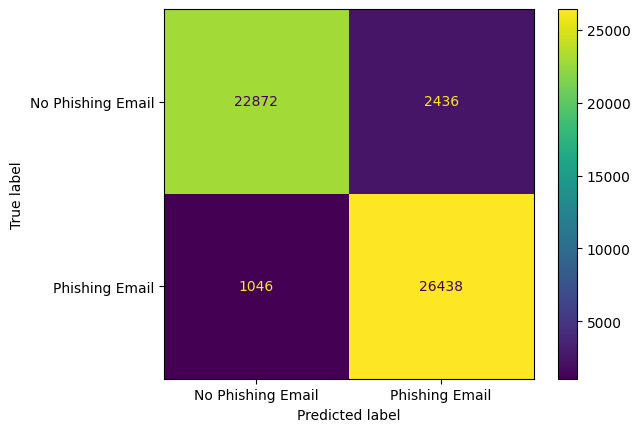

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.90      0.93      6301
   Phishing Email       0.91      0.96      0.94      6896

         accuracy                           0.93     13197
        macro avg       0.93      0.93      0.93     13197
     weighted avg       0.93      0.93      0.93     13197



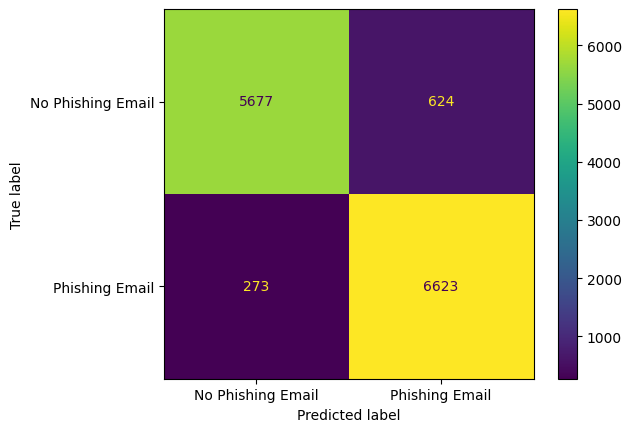


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9420 - loss: 0.1779 - val_accuracy: 0.9528 - val_loss: 0.1643
Epoch 2/50
1650/1650 - 10s - 6ms/step - accuracy: 0.9310 - loss: 0.4097 - val_accuracy: 0.8245 - val_loss: 2.4852
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9242 - loss: 1.0330 - val_accuracy: 0.8991 - val_loss: 1.9115
Epoch 4/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9290 - loss: 1.5863 - val_accuracy: 0.9319 - val_loss: 1.7212
Epoch 5/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9297 - loss: 2.1164 - val_accuracy: 0.8813 - val_loss: 5.4051
Epoch 6/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9284 - loss: 3.1603 - val_accuracy: 0.9448 - val_loss: 2.4312
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1643, stopped at epoch 6

Print History


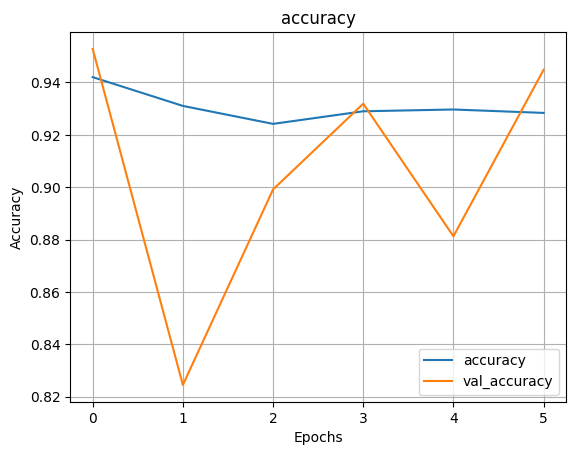

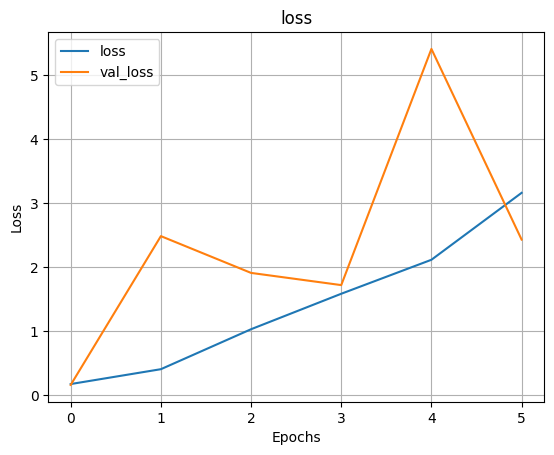

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 656us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.95      0.95     25308
   Phishing Email       0.96      0.95      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



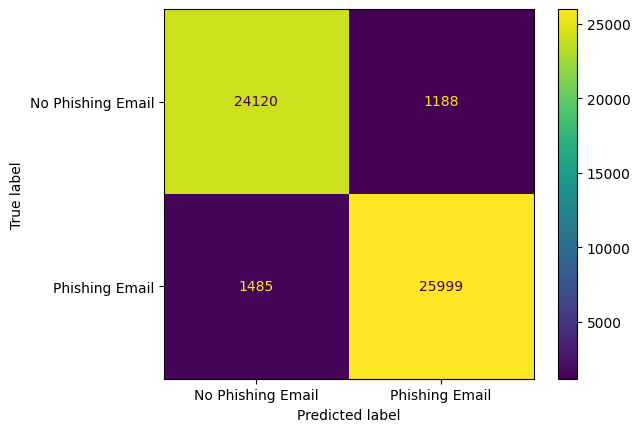

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95      6301
   Phishing Email       0.96      0.95      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



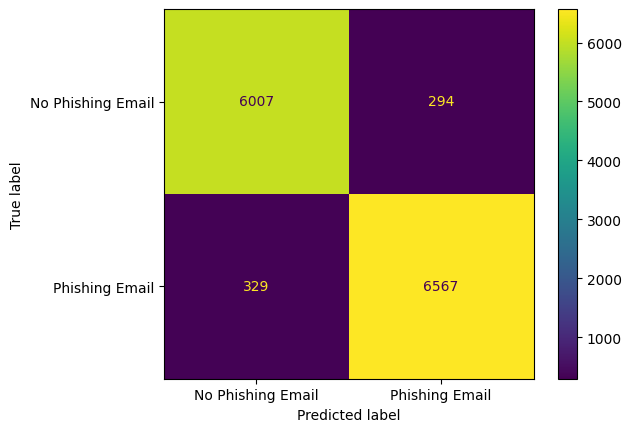


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9420 - loss: 0.1798 - val_accuracy: 0.9542 - val_loss: 0.1736
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9314 - loss: 0.4266 - val_accuracy: 0.9471 - val_loss: 0.3804
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1736, stopped at epoch 2

Print History


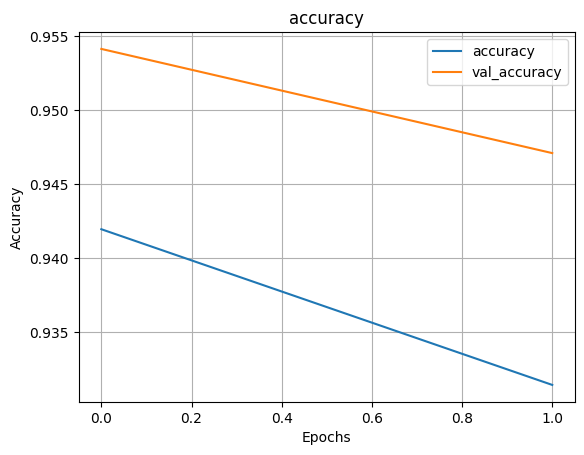

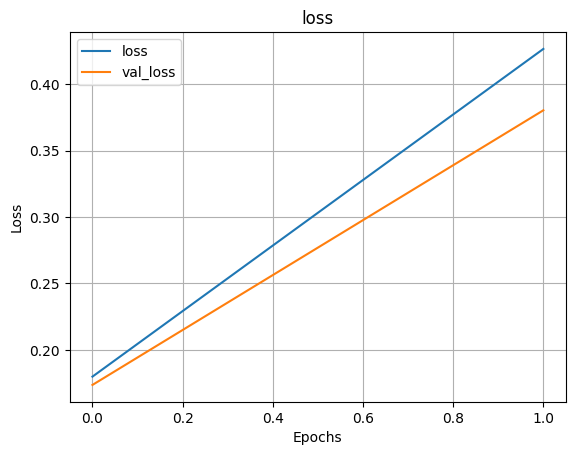

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 655us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.94      0.95     25308
   Phishing Email       0.95      0.97      0.96     27484

         accuracy                           0.95     52792
        macro avg       0.96      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



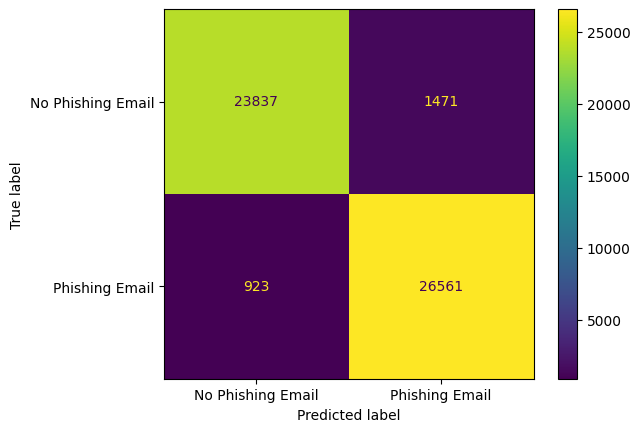

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step
                   precision    recall  f1-score   support

No Phishing Email       0.97      0.94      0.95      6301
   Phishing Email       0.94      0.97      0.96      6896

         accuracy                           0.95     13197
        macro avg       0.96      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



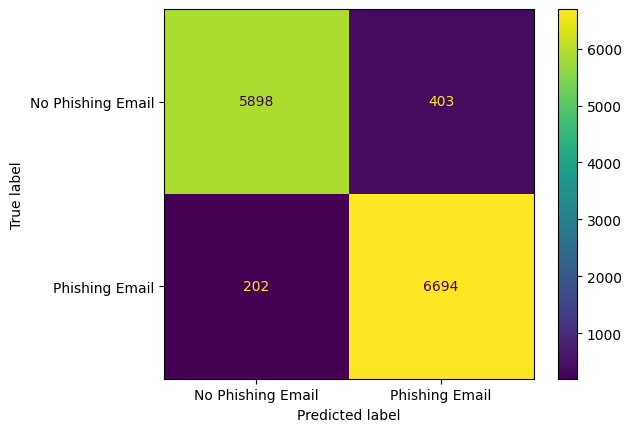


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9398 - loss: 0.1910 - val_accuracy: 0.9420 - val_loss: 0.1986
Epoch 2/100
1650/1650 - 10s - 6ms/step - accuracy: 0.9251 - loss: 0.5023 - val_accuracy: 0.9513 - val_loss: 0.4765
Epoch 3/100
1650/1650 - 10s - 6ms/step - accuracy: 0.9228 - loss: 1.2423 - val_accuracy: 0.9095 - val_loss: 2.1334
Epoch 4/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9270 - loss: 1.8791 - val_accuracy: 0.9480 - val_loss: 1.3534
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1986, stopped at epoch 4

Print History


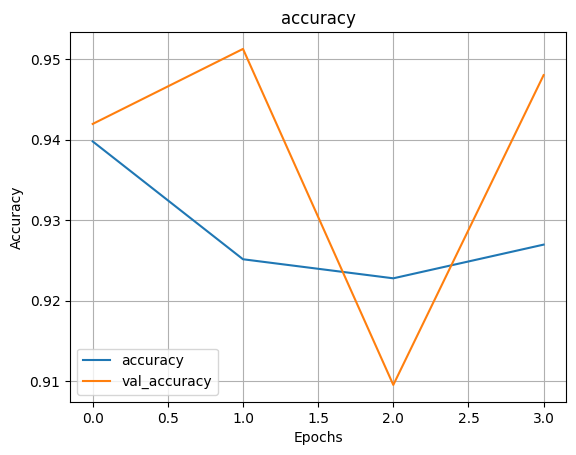

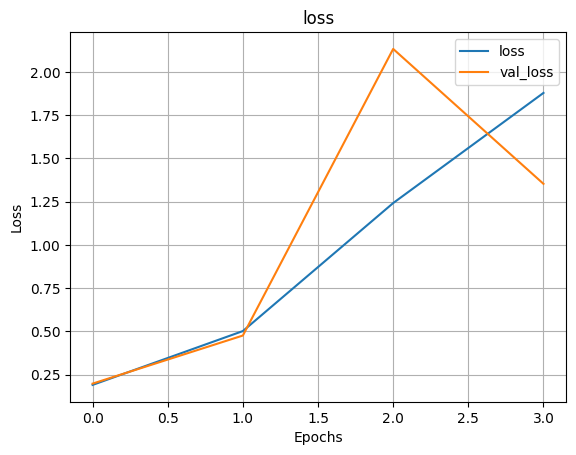

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.95      0.94     25308
   Phishing Email       0.95      0.94      0.94     27484

         accuracy                           0.94     52792
        macro avg       0.94      0.94      0.94     52792
     weighted avg       0.94      0.94      0.94     52792



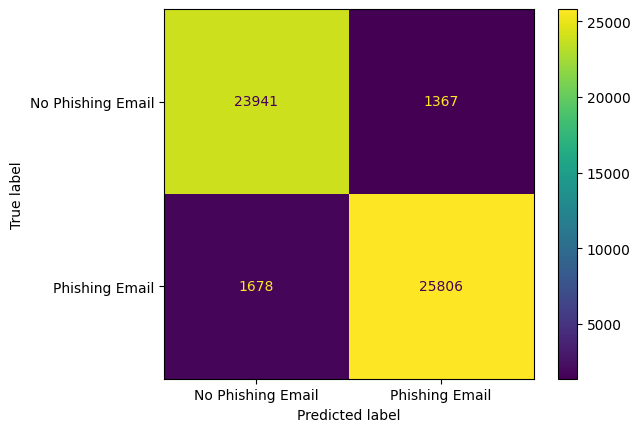

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.94      0.94      6301
   Phishing Email       0.95      0.94      0.94      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



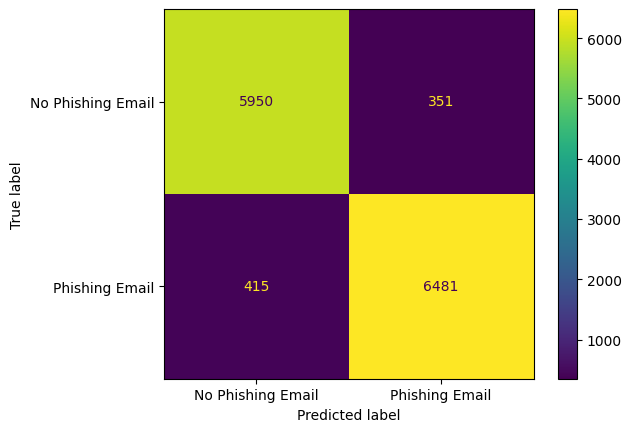


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9418 - loss: 0.1792 - val_accuracy: 0.9470 - val_loss: 0.1841
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9344 - loss: 0.3260 - val_accuracy: 0.9029 - val_loss: 0.5804
Epoch 3/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9269 - loss: 0.7571 - val_accuracy: 0.9007 - val_loss: 1.1692
Epoch 4/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9263 - loss: 1.1666 - val_accuracy: 0.9413 - val_loss: 1.0145
Epoch 5/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9267 - loss: 1.7124 - val_accuracy: 0.9478 - val_loss: 1.1473
Epoch 6/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9224 - loss: 2.6494 - val_accuracy: 0.9042 - val_loss: 3.8954
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1841, stopped at epoch 6

Print History


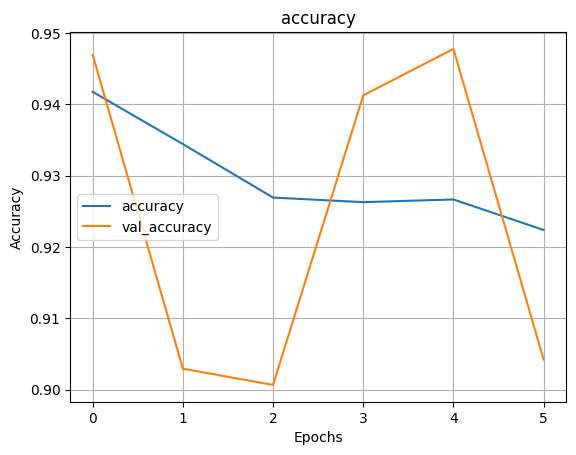

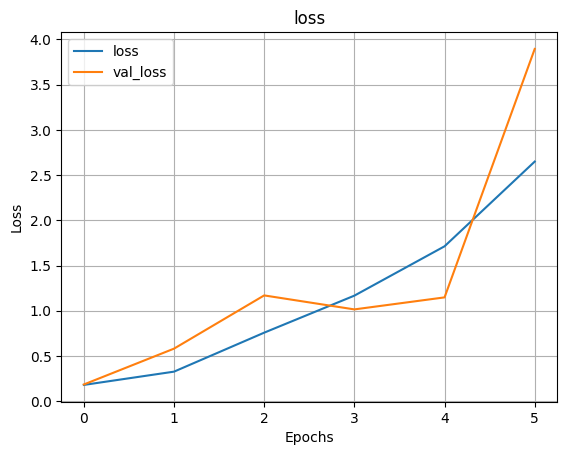

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 656us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.93      0.94     25308
   Phishing Email       0.94      0.96      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



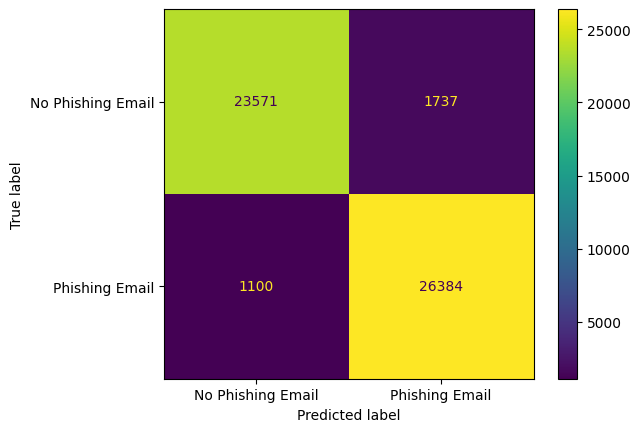

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.93      0.94      6301
   Phishing Email       0.94      0.96      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



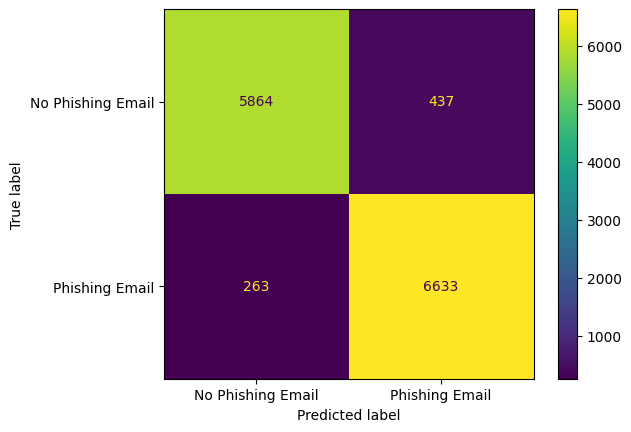


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9417 - loss: 0.1783 - val_accuracy: 0.9368 - val_loss: 0.2223
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9286 - loss: 0.4481 - val_accuracy: 0.9259 - val_loss: 0.6305
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.2223, stopped at epoch 2

Print History


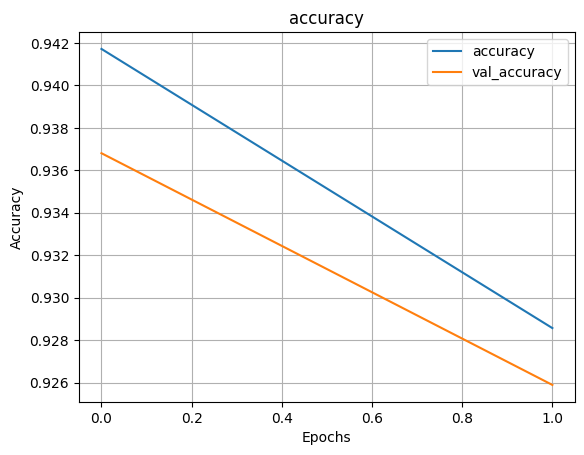

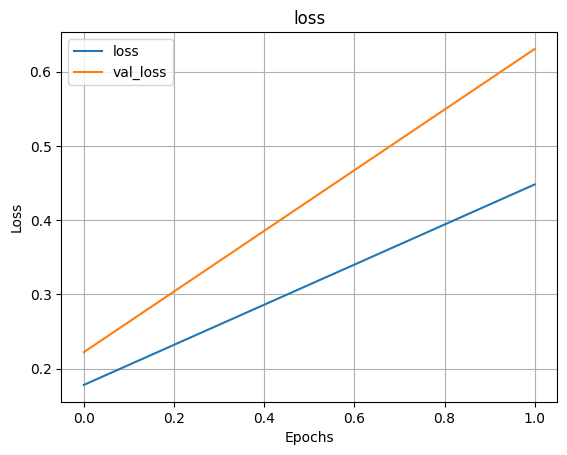

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 659us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.94      0.93     25308
   Phishing Email       0.94      0.94      0.94     27484

         accuracy                           0.94     52792
        macro avg       0.94      0.94      0.94     52792
     weighted avg       0.94      0.94      0.94     52792



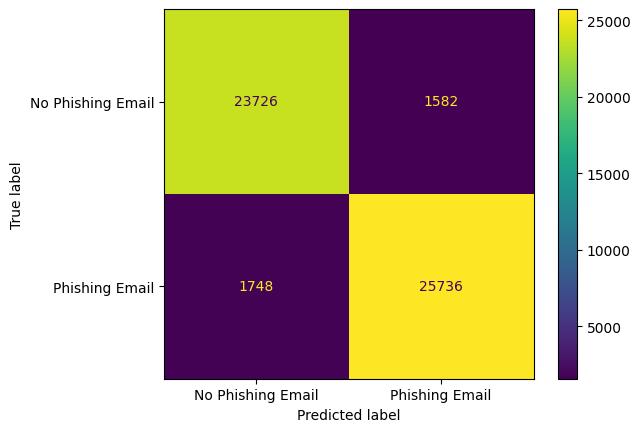

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.94      0.93      6301
   Phishing Email       0.94      0.94      0.94      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



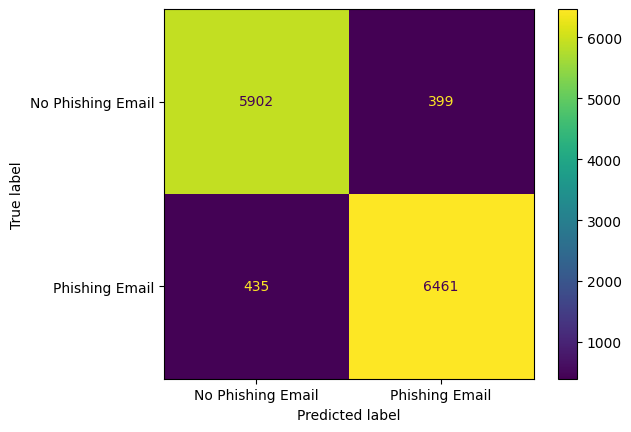


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9393 - loss: 0.1959 - val_accuracy: 0.9446 - val_loss: 0.2313
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9301 - loss: 0.4400 - val_accuracy: 0.9203 - val_loss: 0.8044
Epoch 3/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9221 - loss: 1.0874 - val_accuracy: 0.9373 - val_loss: 1.1469
Epoch 4/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9286 - loss: 1.5559 - val_accuracy: 0.9207 - val_loss: 1.7517
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.2313, stopped at epoch 4

Print History


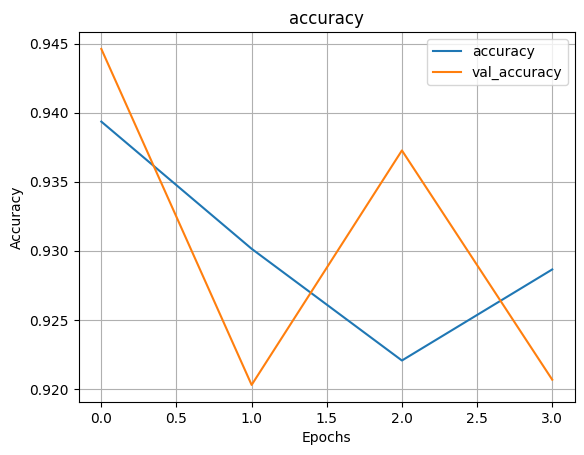

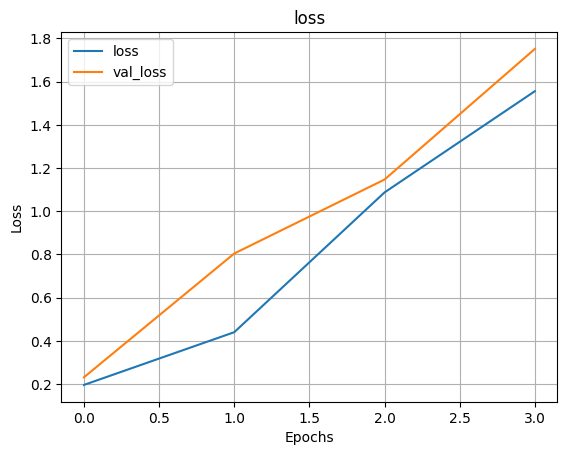

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 654us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.94      0.94     25308
   Phishing Email       0.94      0.95      0.95     27484

         accuracy                           0.94     52792
        macro avg       0.94      0.94      0.94     52792
     weighted avg       0.94      0.94      0.94     52792



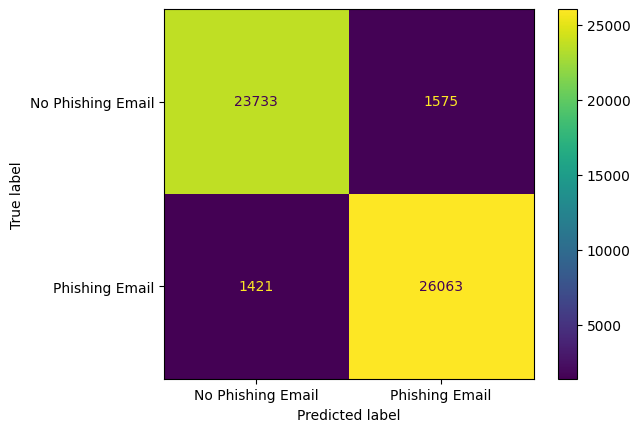

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.94      6301
   Phishing Email       0.94      0.95      0.95      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



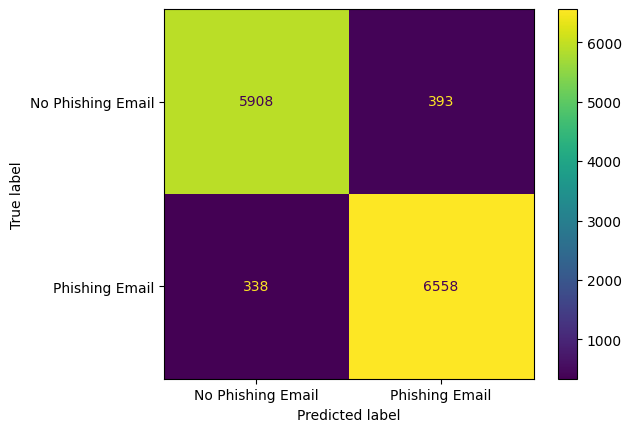


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9409 - loss: 0.1809 - val_accuracy: 0.9498 - val_loss: 0.1822
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9259 - loss: 0.5949 - val_accuracy: 0.9206 - val_loss: 1.0523
Epoch 3/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9269 - loss: 1.3600 - val_accuracy: 0.9548 - val_loss: 0.7897
Epoch 4/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9276 - loss: 2.1254 - val_accuracy: 0.9482 - val_loss: 1.5271
Epoch 5/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9298 - loss: 2.8738 - val_accuracy: 0.9173 - val_loss: 4.0133
Epoch 6/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9241 - loss: 4.7937 - val_accuracy: 0.8823 - val_loss: 11.0422
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1822, stopped at epoch 6

Print History


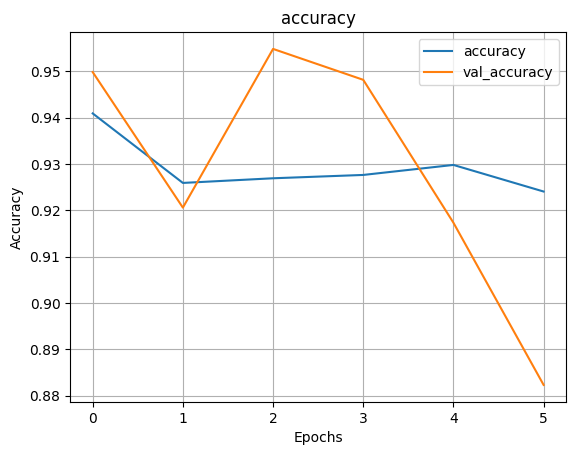

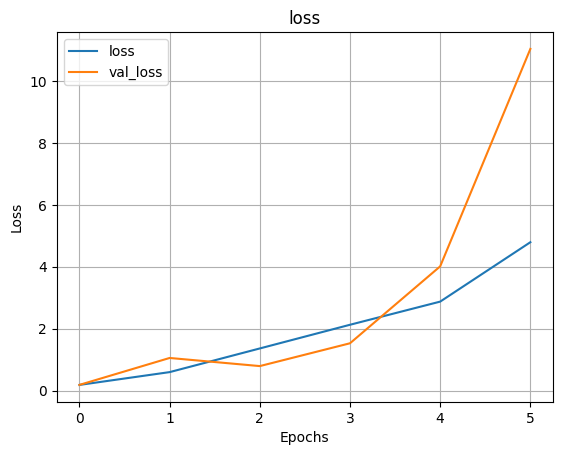

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 659us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.96      0.95     25308
   Phishing Email       0.96      0.94      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



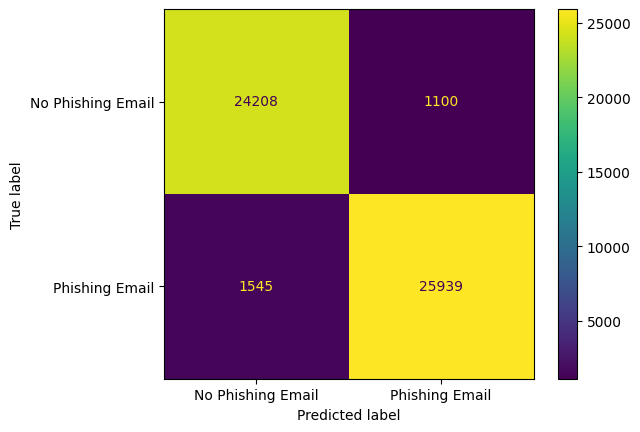

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.95      0.95      6301
   Phishing Email       0.96      0.95      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



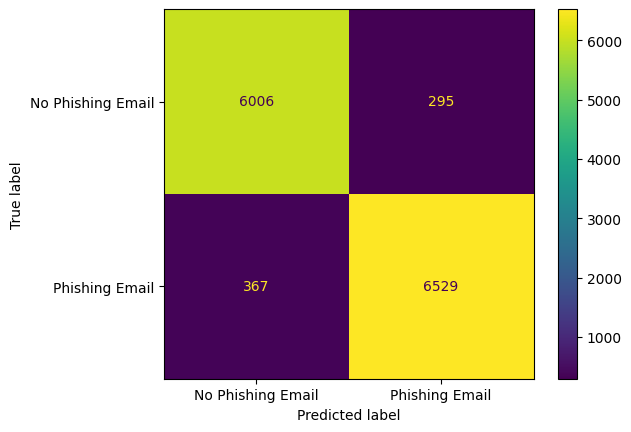


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.8916 - loss: 55.9411 - val_accuracy: 0.9354 - val_loss: 118.2429
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.8981 - loss: 563.7410 - val_accuracy: 0.9117 - val_loss: 840.0823
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=118.2429, stopped at epoch 2

Print History


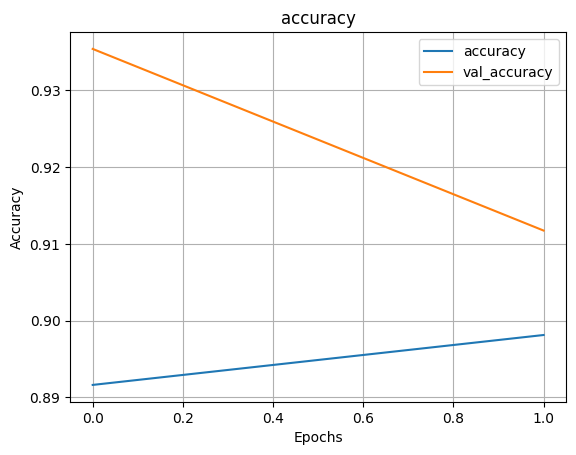

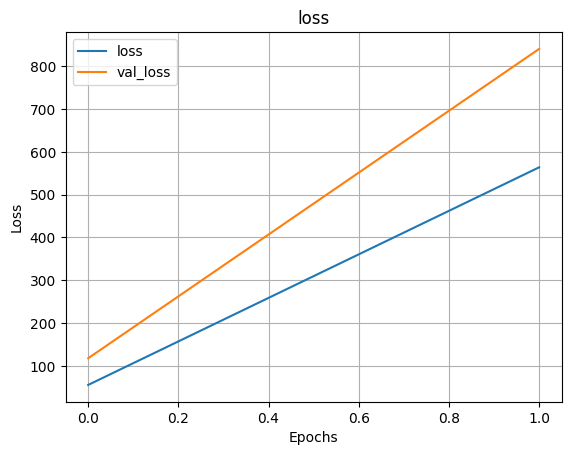

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.92      0.93     25308
   Phishing Email       0.93      0.95      0.94     27484

         accuracy                           0.93     52792
        macro avg       0.94      0.93      0.93     52792
     weighted avg       0.94      0.93      0.93     52792



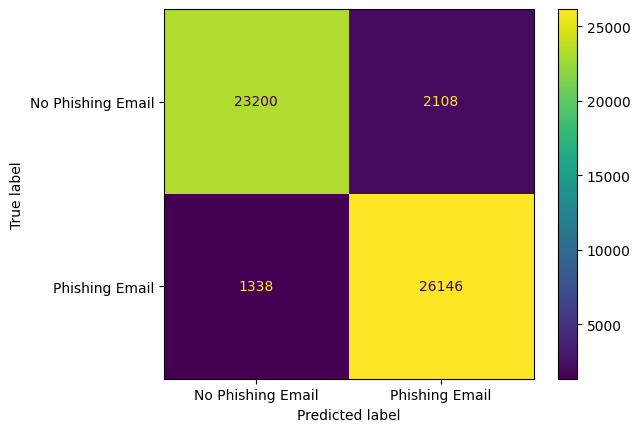

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.92      0.93      6301
   Phishing Email       0.93      0.95      0.94      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.93      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



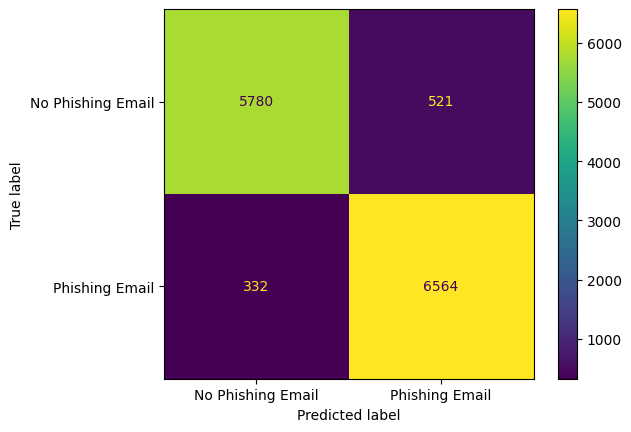


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.8887 - loss: 96.0373 - val_accuracy: 0.9439 - val_loss: 123.2870
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9039 - loss: 689.7913 - val_accuracy: 0.9261 - val_loss: 666.7191
Epoch 3/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9145 - loss: 1484.1230 - val_accuracy: 0.9564 - val_loss: 669.7166
Epoch 4/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9129 - loss: 3231.7158 - val_accuracy: 0.9124 - val_loss: 3392.5891
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=123.2870, stopped at epoch 4

Print History


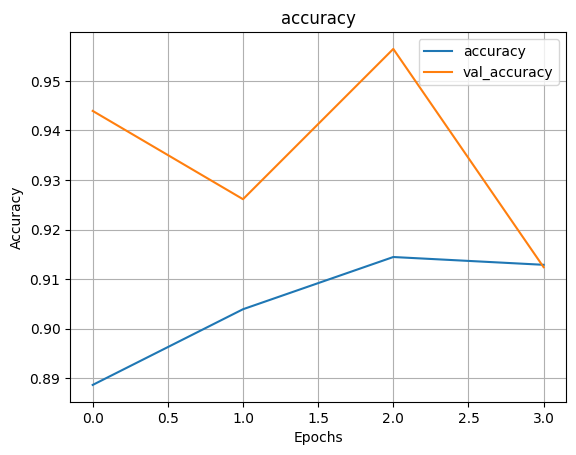

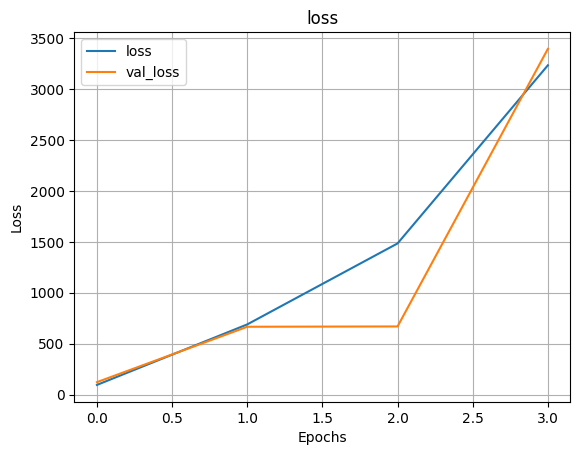

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 683us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.95      0.94     25308
   Phishing Email       0.95      0.94      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.94      0.95      0.94     52792
     weighted avg       0.95      0.95      0.95     52792



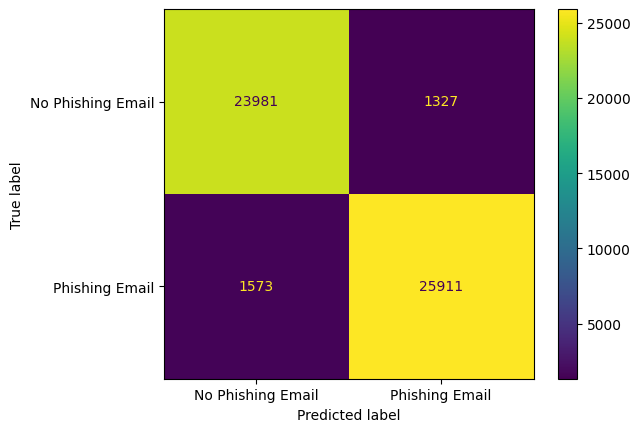

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.94      0.94      6301
   Phishing Email       0.95      0.95      0.95      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



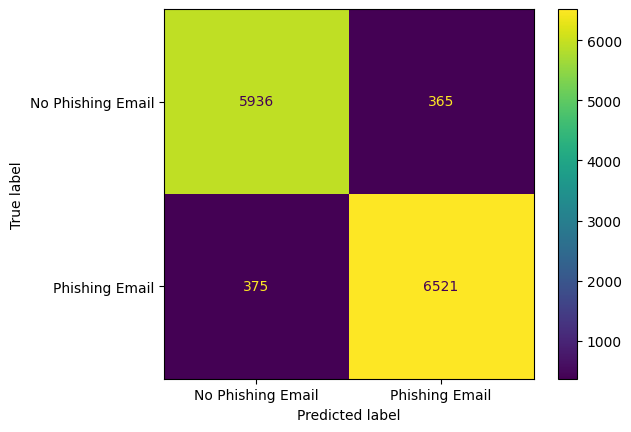


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8935 - loss: 34.1689 - val_accuracy: 0.8850 - val_loss: 129.4393
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.8966 - loss: 376.0612 - val_accuracy: 0.8737 - val_loss: 747.5140
Epoch 3/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9009 - loss: 1144.1904 - val_accuracy: 0.9435 - val_loss: 662.8192
Epoch 4/50
1650/1650 - 11s - 7ms/step - accuracy: 0.8966 - loss: 3488.9175 - val_accuracy: 0.9457 - val_loss: 1769.7451
Epoch 5/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9135 - loss: 3524.2300 - val_accuracy: 0.9161 - val_loss: 3899.1218
Epoch 6/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9102 - loss: 5749.9434 - val_accuracy: 0.9379 - val_loss: 3493.5627
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=129.4393, stopped at epoch 6

Print History


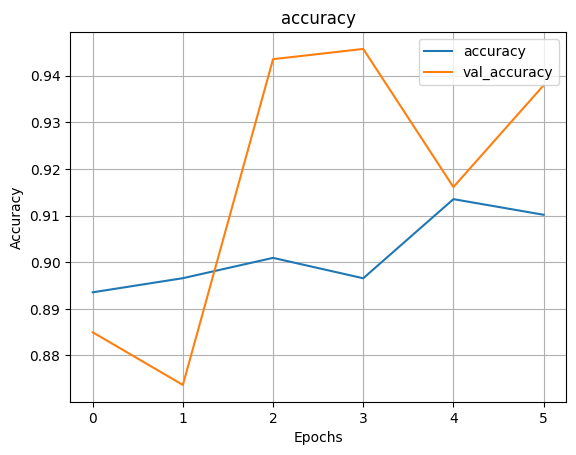

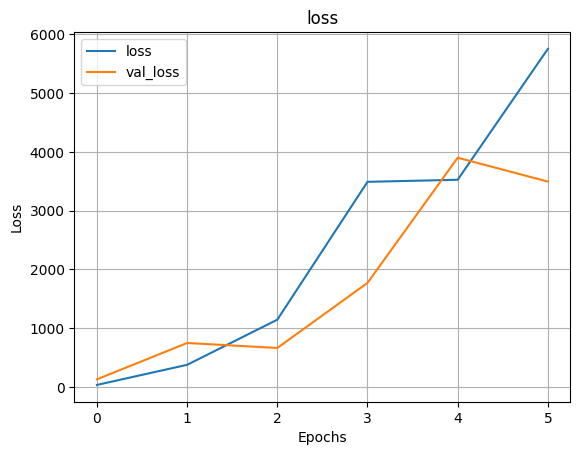

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step
                   precision    recall  f1-score   support

No Phishing Email       0.86      0.91      0.88     25308
   Phishing Email       0.91      0.86      0.89     27484

         accuracy                           0.88     52792
        macro avg       0.88      0.88      0.88     52792
     weighted avg       0.89      0.88      0.88     52792



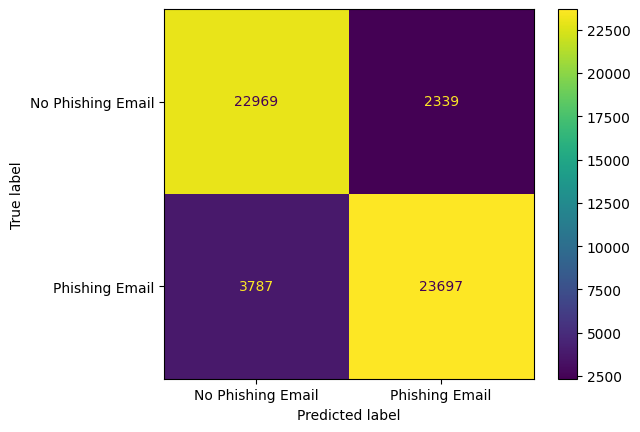

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step
                   precision    recall  f1-score   support

No Phishing Email       0.86      0.91      0.88      6301
   Phishing Email       0.91      0.86      0.89      6896

         accuracy                           0.88     13197
        macro avg       0.89      0.89      0.88     13197
     weighted avg       0.89      0.88      0.89     13197



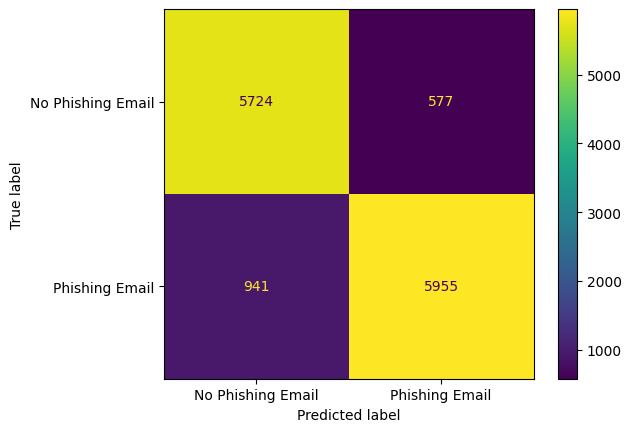


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8884 - loss: 77.6901 - val_accuracy: 0.9484 - val_loss: 84.4116
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9031 - loss: 570.6420 - val_accuracy: 0.9379 - val_loss: 405.9706
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=84.4116, stopped at epoch 2

Print History


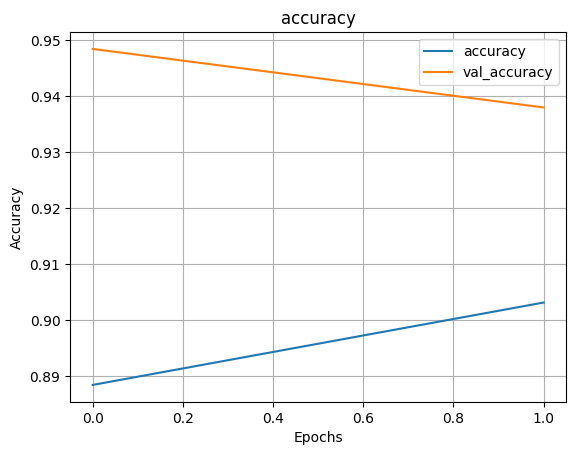

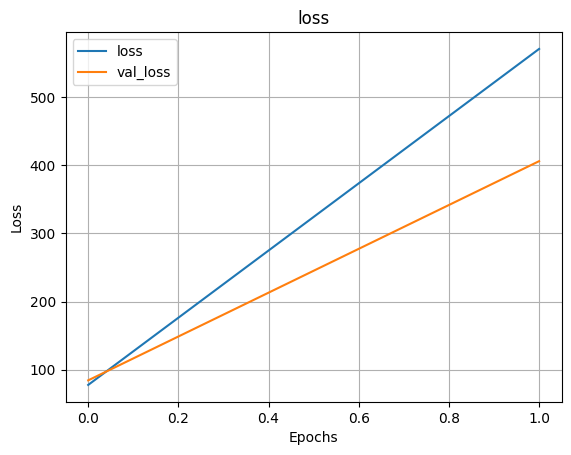

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95     25308
   Phishing Email       0.95      0.95      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



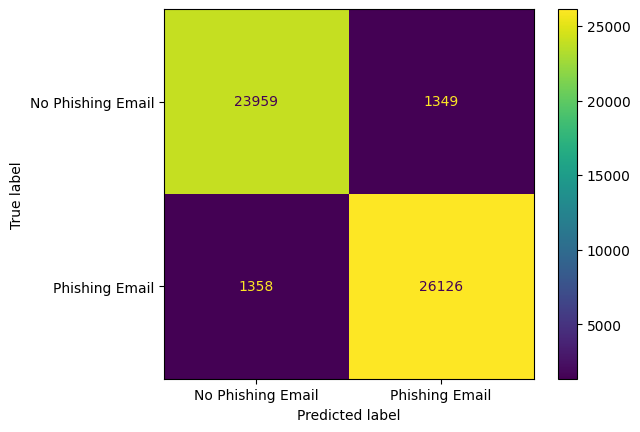

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.95      6301
   Phishing Email       0.95      0.95      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



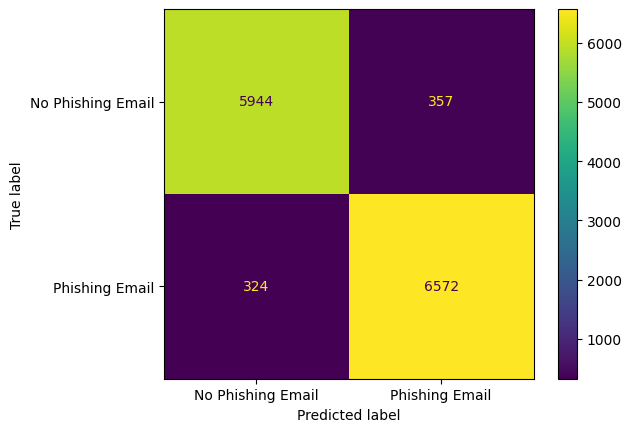


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.8888 - loss: 68.9779 - val_accuracy: 0.9492 - val_loss: 74.3888
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9020 - loss: 602.6573 - val_accuracy: 0.9233 - val_loss: 752.8304
Epoch 3/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9057 - loss: 1783.2216 - val_accuracy: 0.9504 - val_loss: 880.2558
Epoch 4/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9115 - loss: 3139.4128 - val_accuracy: 0.9519 - val_loss: 1428.6136
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=74.3888, stopped at epoch 4

Print History


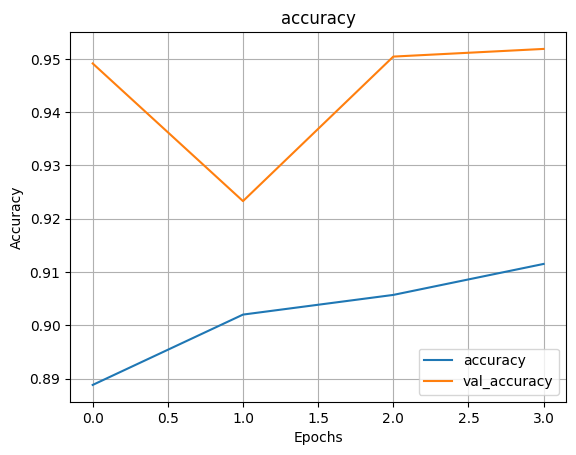

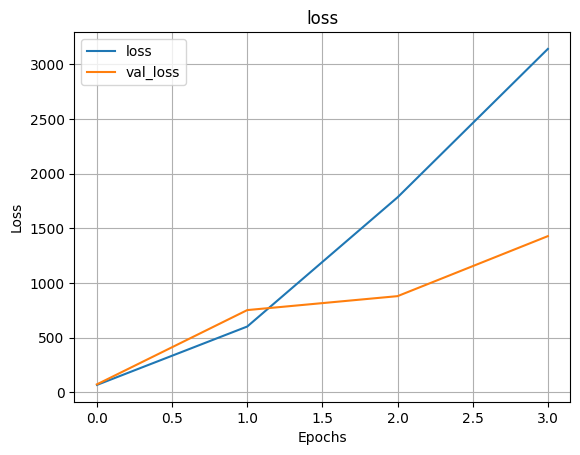

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 675us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.94     25308
   Phishing Email       0.94      0.96      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



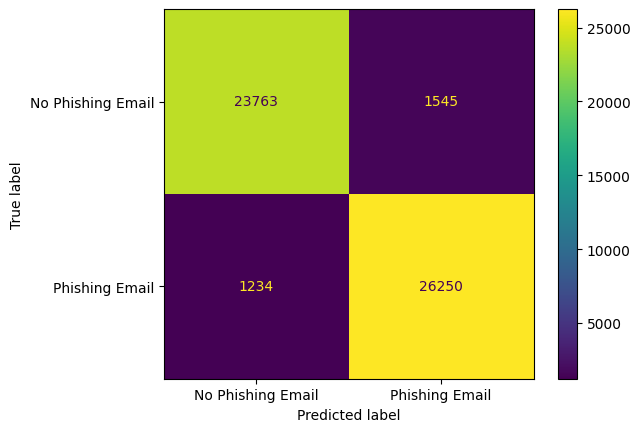

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.95      6301
   Phishing Email       0.95      0.96      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



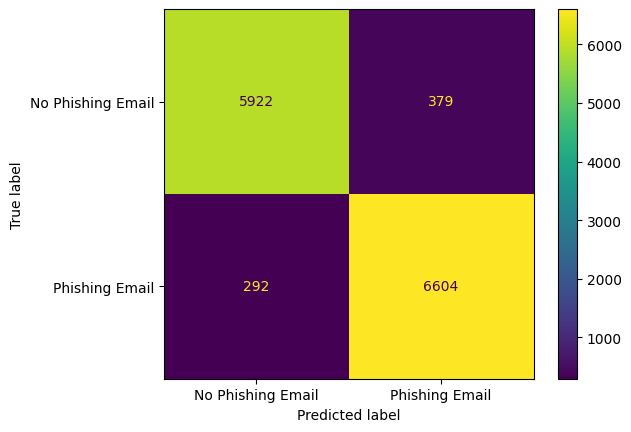


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.9012 - loss: 19.0825 - val_accuracy: 0.8794 - val_loss: 86.1143
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9102 - loss: 237.6913 - val_accuracy: 0.9473 - val_loss: 199.5867
Epoch 3/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9180 - loss: 670.7294 - val_accuracy: 0.8300 - val_loss: 2562.8252
Epoch 4/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9156 - loss: 1467.2579 - val_accuracy: 0.9279 - val_loss: 1333.9703
Epoch 5/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9203 - loss: 2082.6594 - val_accuracy: 0.9032 - val_loss: 3281.8950
Epoch 6/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9174 - loss: 3588.6316 - val_accuracy: 0.9498 - val_loss: 1816.0211
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=86.1143, stopped at epoch 6

Print History


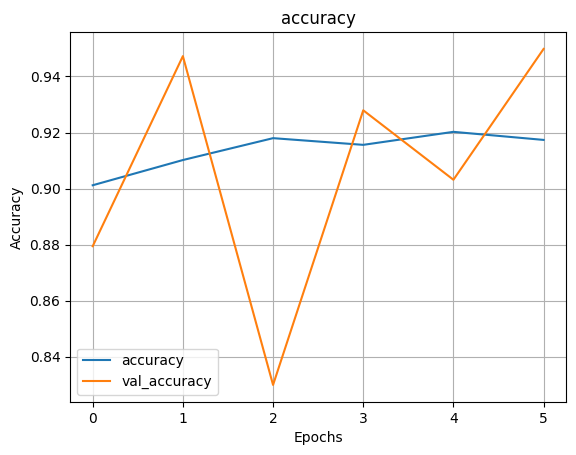

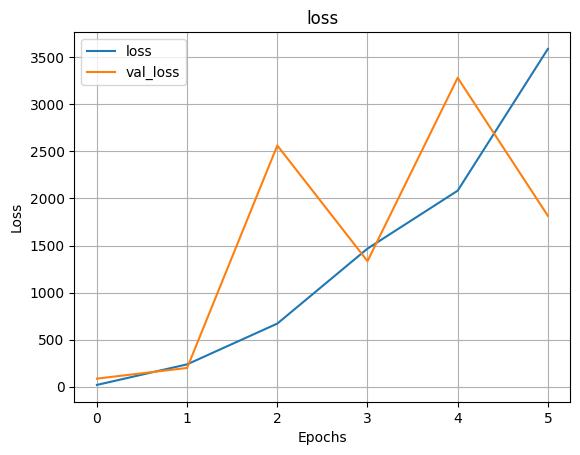

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 683us/step
                   precision    recall  f1-score   support

No Phishing Email       0.90      0.84      0.87     25308
   Phishing Email       0.86      0.91      0.89     27484

         accuracy                           0.88     52792
        macro avg       0.88      0.88      0.88     52792
     weighted avg       0.88      0.88      0.88     52792



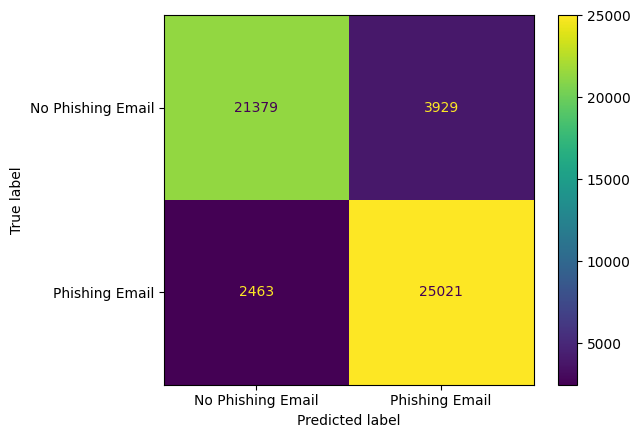

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step
                   precision    recall  f1-score   support

No Phishing Email       0.90      0.84      0.87      6301
   Phishing Email       0.86      0.92      0.89      6896

         accuracy                           0.88     13197
        macro avg       0.88      0.88      0.88     13197
     weighted avg       0.88      0.88      0.88     13197



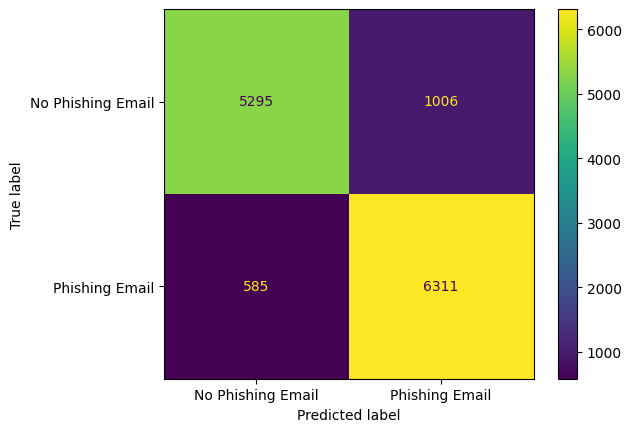


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.9059 - loss: 20.4229 - val_accuracy: 0.9051 - val_loss: 66.8067
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9103 - loss: 238.0307 - val_accuracy: 0.9492 - val_loss: 190.1024
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=66.8067, stopped at epoch 2

Print History


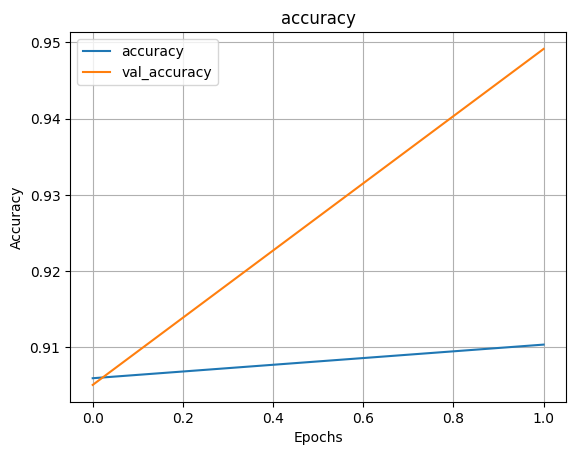

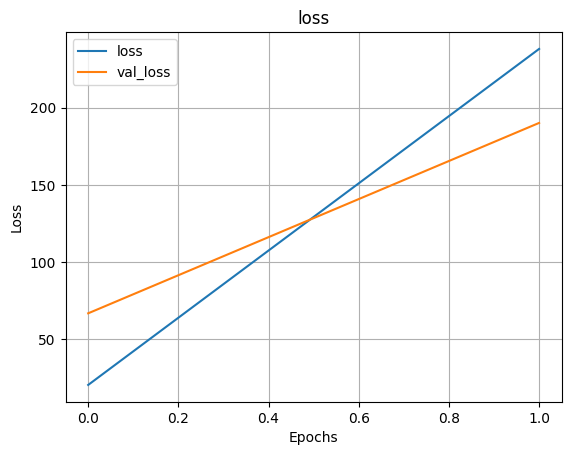

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 691us/step
                   precision    recall  f1-score   support

No Phishing Email       0.91      0.88      0.90     25308
   Phishing Email       0.90      0.92      0.91     27484

         accuracy                           0.90     52792
        macro avg       0.90      0.90      0.90     52792
     weighted avg       0.90      0.90      0.90     52792



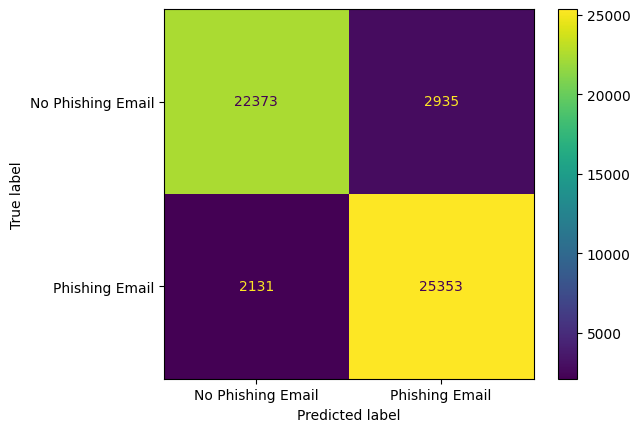

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.88      0.90      6301
   Phishing Email       0.90      0.93      0.91      6896

         accuracy                           0.91     13197
        macro avg       0.91      0.90      0.90     13197
     weighted avg       0.91      0.91      0.90     13197



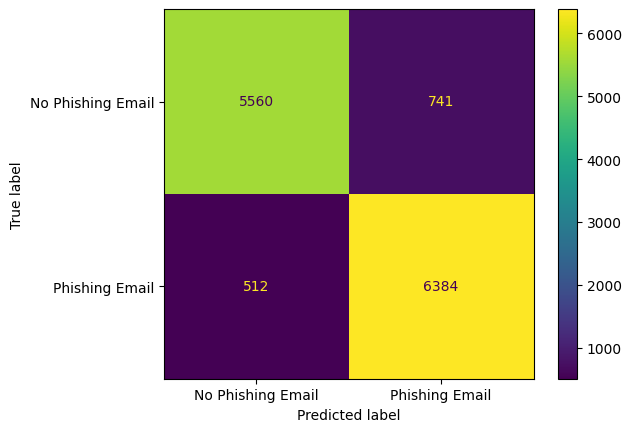


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.8868 - loss: 73.9460 - val_accuracy: 0.9336 - val_loss: 160.5689
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9014 - loss: 580.1001 - val_accuracy: 0.9286 - val_loss: 552.4575
Epoch 3/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9026 - loss: 1693.7572 - val_accuracy: 0.7699 - val_loss: 5709.7910
Epoch 4/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9082 - loss: 2824.1003 - val_accuracy: 0.9455 - val_loss: 1280.6001
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=160.5689, stopped at epoch 4

Print History


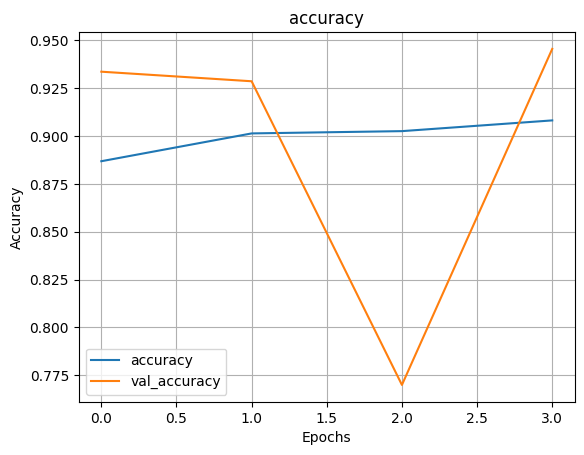

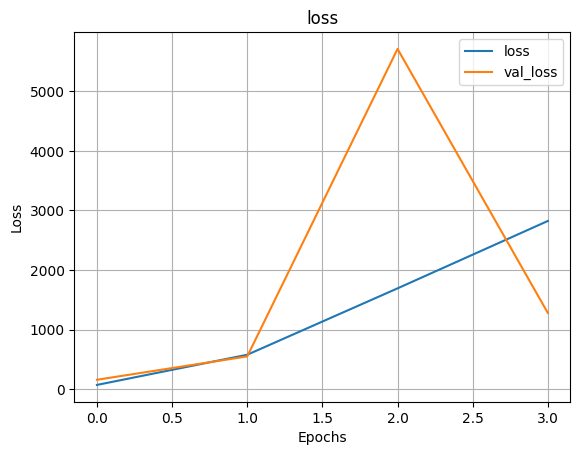

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.94      0.93     25308
   Phishing Email       0.94      0.93      0.94     27484

         accuracy                           0.93     52792
        macro avg       0.93      0.93      0.93     52792
     weighted avg       0.93      0.93      0.93     52792



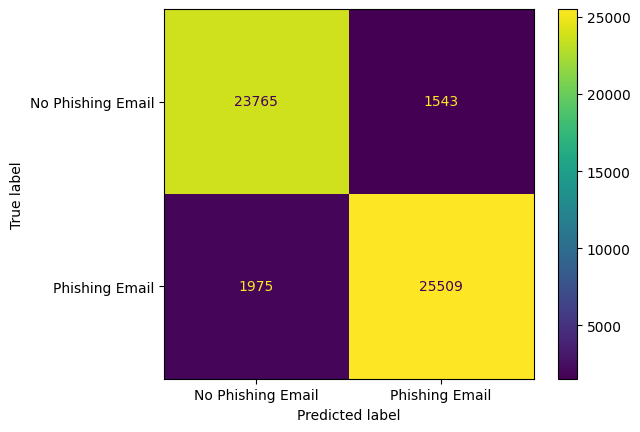

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.93      0.93      6301
   Phishing Email       0.94      0.93      0.94      6896

         accuracy                           0.93     13197
        macro avg       0.93      0.93      0.93     13197
     weighted avg       0.93      0.93      0.93     13197



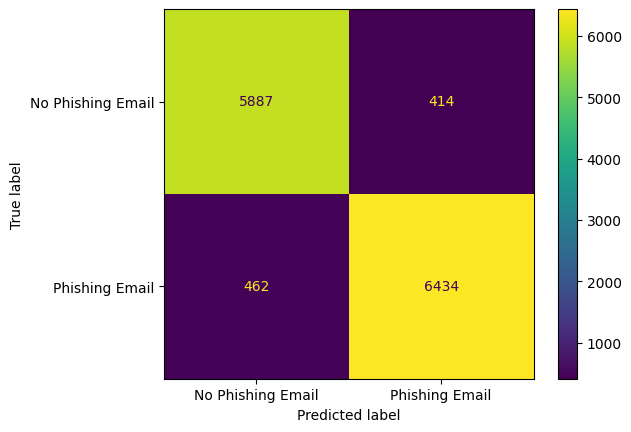


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.8994 - loss: 32.5848 - val_accuracy: 0.9287 - val_loss: 62.3069
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9053 - loss: 372.3196 - val_accuracy: 0.8716 - val_loss: 899.2759
Epoch 3/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9133 - loss: 850.0748 - val_accuracy: 0.7921 - val_loss: 5159.1094
Epoch 4/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9163 - loss: 1561.5117 - val_accuracy: 0.9351 - val_loss: 1293.1956
Epoch 5/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9121 - loss: 3038.4272 - val_accuracy: 0.9302 - val_loss: 2528.7563
Epoch 6/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9190 - loss: 3865.7400 - val_accuracy: 0.9329 - val_loss: 2998.0732
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=62.3069, stopped at epoch 6

Print History


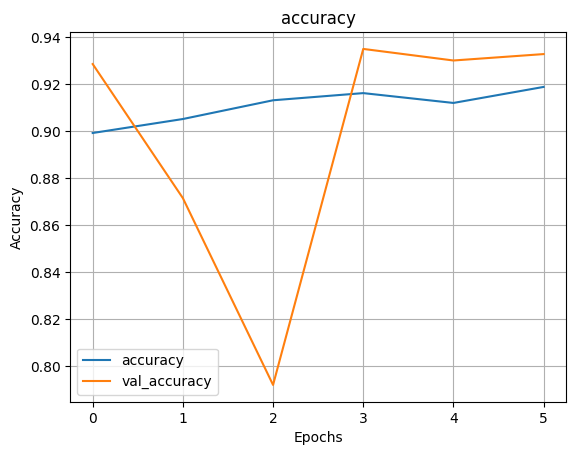

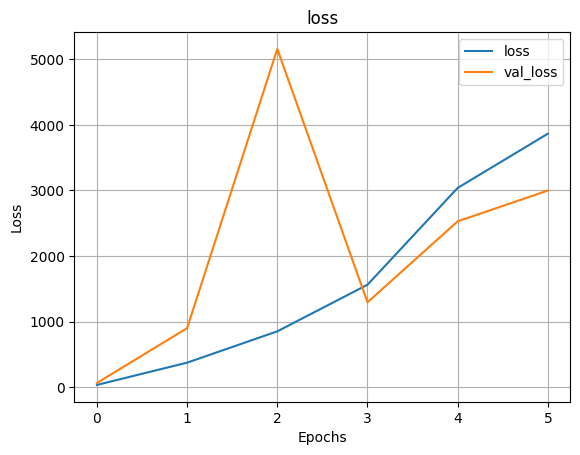

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 683us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.94      0.93     25308
   Phishing Email       0.94      0.92      0.93     27484

         accuracy                           0.93     52792
        macro avg       0.93      0.93      0.93     52792
     weighted avg       0.93      0.93      0.93     52792



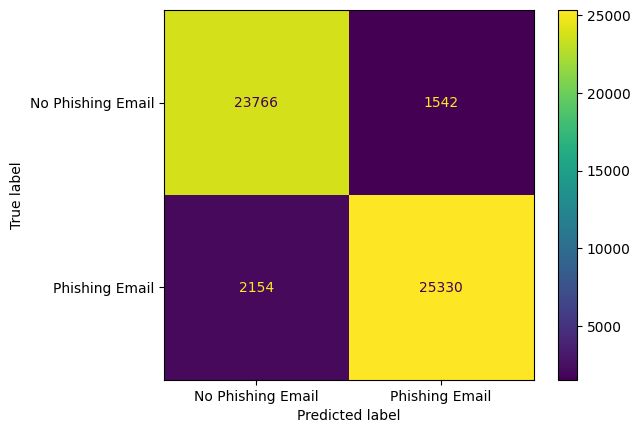

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.94      0.93      6301
   Phishing Email       0.94      0.92      0.93      6896

         accuracy                           0.93     13197
        macro avg       0.93      0.93      0.93     13197
     weighted avg       0.93      0.93      0.93     13197



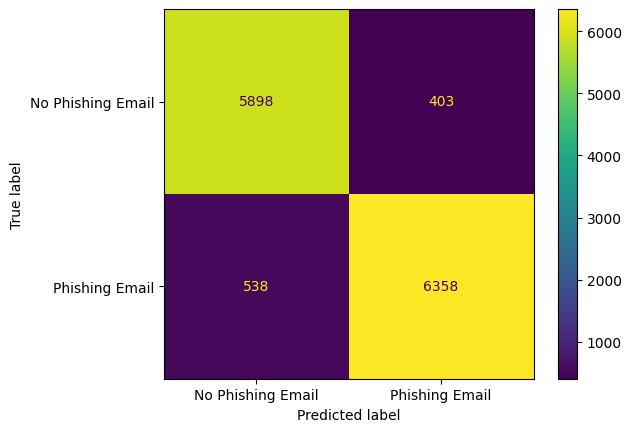


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8963 - loss: 41.4113 - val_accuracy: 0.7922 - val_loss: 401.0811
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.8962 - loss: 510.7075 - val_accuracy: 0.9498 - val_loss: 270.5781
Epoch 3/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9072 - loss: 1254.8643 - val_accuracy: 0.9428 - val_loss: 621.0651
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=270.5781, stopped at epoch 3

Print History


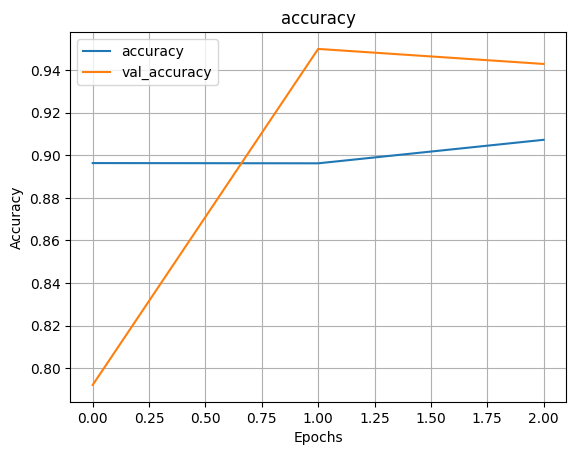

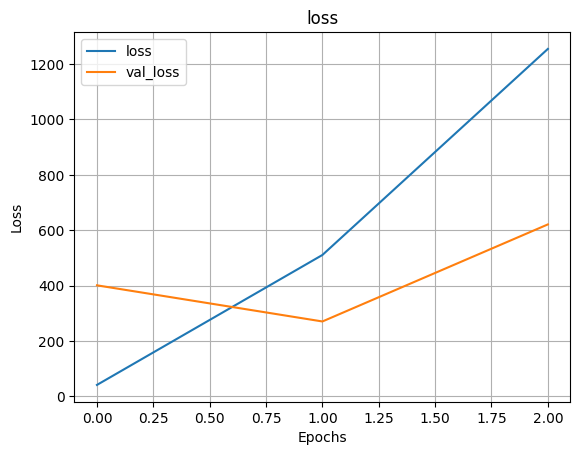

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95     25308
   Phishing Email       0.95      0.95      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



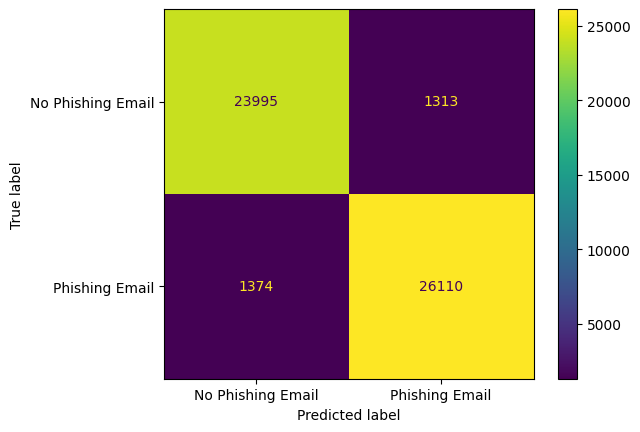

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95      6301
   Phishing Email       0.95      0.95      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



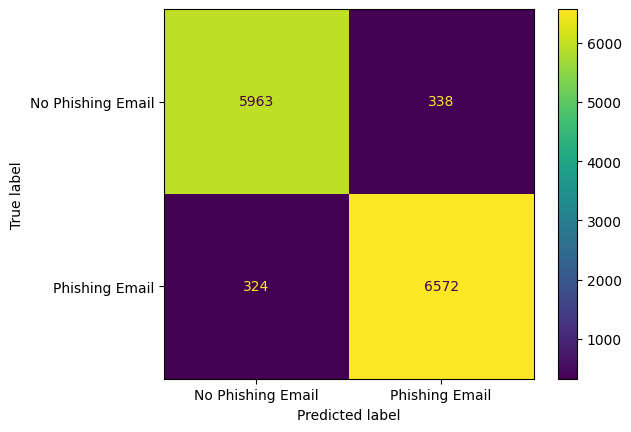


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.9006 - loss: 20.2830 - val_accuracy: 0.8486 - val_loss: 143.3671
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9043 - loss: 285.5077 - val_accuracy: 0.9550 - val_loss: 177.6987
Epoch 3/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9096 - loss: 765.8560 - val_accuracy: 0.9310 - val_loss: 744.5269
Epoch 4/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9121 - loss: 1622.3234 - val_accuracy: 0.9102 - val_loss: 1546.0596
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=143.3671, stopped at epoch 4

Print History


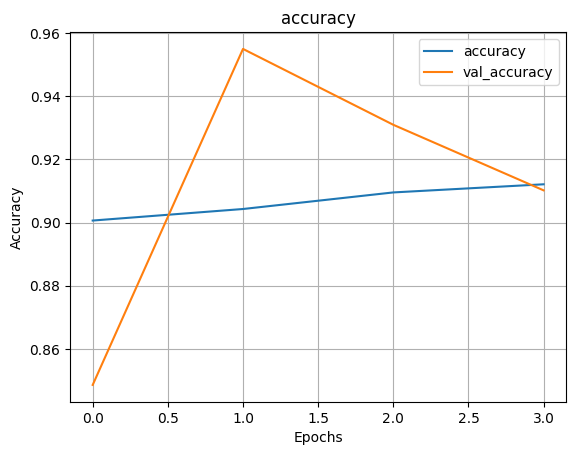

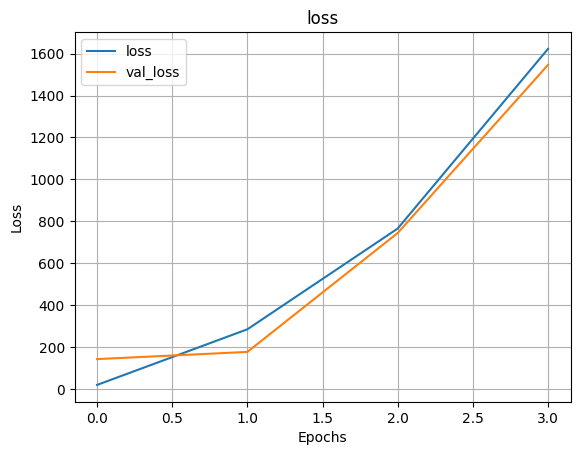

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step
                   precision    recall  f1-score   support

No Phishing Email       0.80      0.90      0.85     25308
   Phishing Email       0.90      0.79      0.84     27484

         accuracy                           0.85     52792
        macro avg       0.85      0.85      0.85     52792
     weighted avg       0.85      0.85      0.85     52792



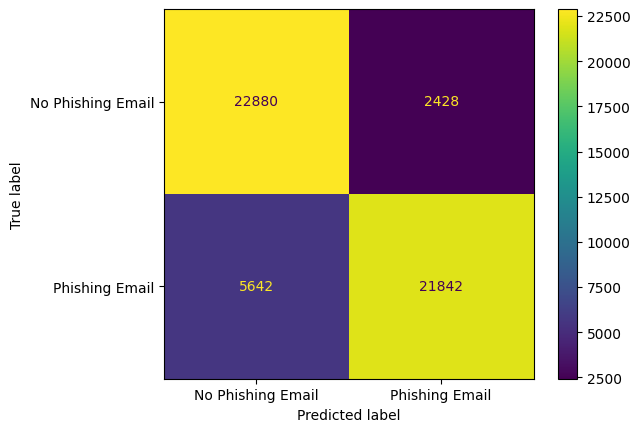

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step
                   precision    recall  f1-score   support

No Phishing Email       0.80      0.91      0.85      6301
   Phishing Email       0.90      0.80      0.85      6896

         accuracy                           0.85     13197
        macro avg       0.85      0.85      0.85     13197
     weighted avg       0.85      0.85      0.85     13197



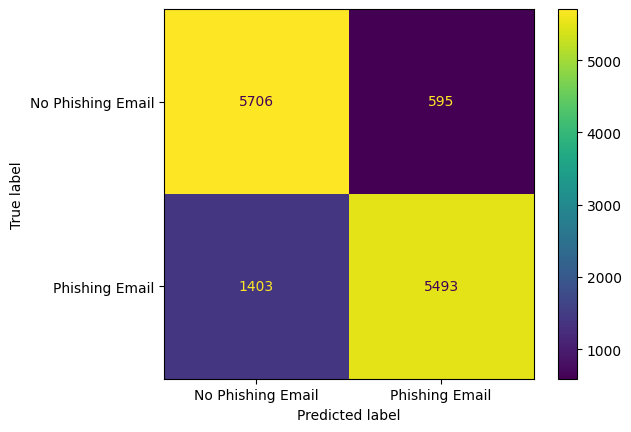


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.9073 - loss: 15.1558 - val_accuracy: 0.9500 - val_loss: 17.4819
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9116 - loss: 194.0868 - val_accuracy: 0.9511 - val_loss: 129.9928
Epoch 3/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9127 - loss: 735.5076 - val_accuracy: 0.9426 - val_loss: 500.0367
Epoch 4/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9186 - loss: 1415.1688 - val_accuracy: 0.9367 - val_loss: 1123.1278
Epoch 5/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9215 - loss: 2106.7505 - val_accuracy: 0.9446 - val_loss: 1374.4869
Epoch 6/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9229 - loss: 3504.1716 - val_accuracy: 0.9473 - val_loss: 1997.6586
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=17.4819, stopped at epoch 6

Print History


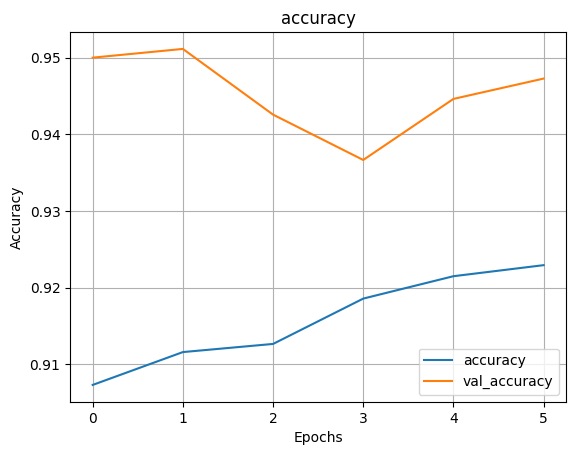

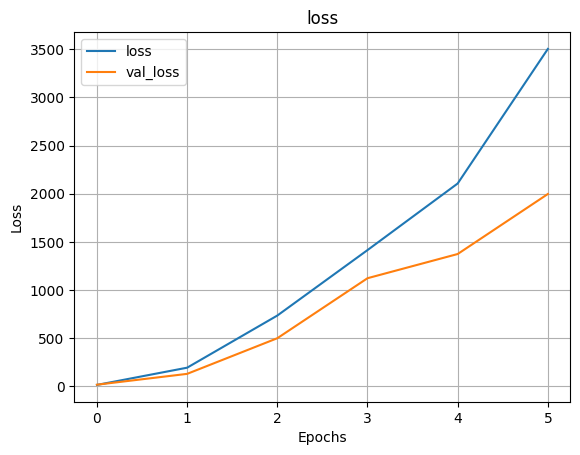

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95     25308
   Phishing Email       0.95      0.95      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



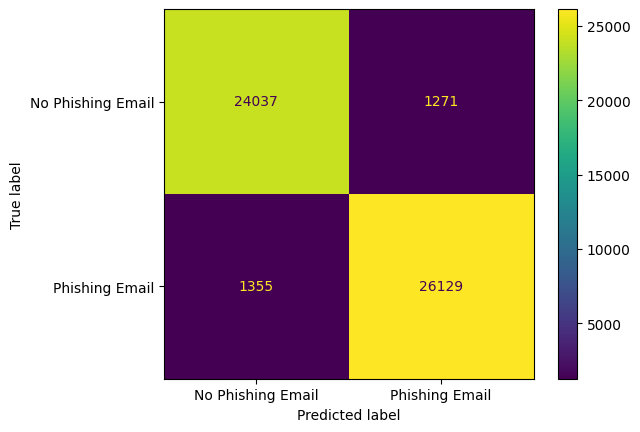

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95      6301
   Phishing Email       0.95      0.95      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



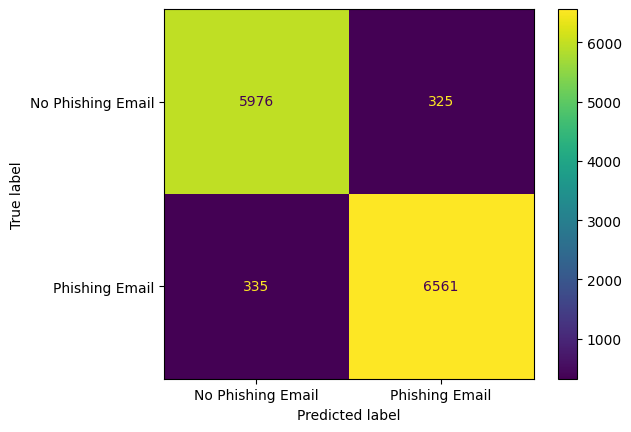

In [7]:
# Loop through all combinations of hyperparameters
for layers in layer_configs:
    for epochs in epochs_list:
        for min_delta in min_deltas:
            for patience in patiences:
                
                # Build the MLP model with specified layer configuration
                model = Sequential()
                
                # Add the input layer and the first hidden layer
                model.add(Dense(layers[0], activation='relu', input_shape=(X_train.shape[1],)))
                
                # Add any additional hidden layers
                for units in layers[1:]:
                    model.add(Dense(units, activation='relu'))
                
                # Add the output layer with sigmoid activation for binary classification
                model.add(Dense(1, activation='sigmoid'))

                # Compile the model with Adam optimizer and binary cross-entropy loss
                model.compile(optimizer=Adam(learning_rate=1e-3),
                              loss='binary_crossentropy',
                              metrics=['accuracy'])

                # Define EarlyStopping to stop training if val_loss doesn't improve
                early_stopping = EarlyStopping(
                    monitor='val_loss',       # Monitor validation loss
                    min_delta=min_delta,      # Minimum change to qualify as improvement
                    patience=patience,        # How many epochs to wait before stopping
                    restore_best_weights=True,# Restore weights from best epoch
                    verbose=1,
                    mode='min'                # Looking for minimum val_loss
                )

                # Define TimeStopping to stop training if it exceeds time limit
                time_stopping = TimeStopping(max_seconds=300)

                # Print current model configuration
                print(f"\nConfig: layers={layers}, epochs={epochs}, "
                      f"min_delta={min_delta}, patience={patience}")

                # Train the model with early stopping and time stopping callbacks
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=epochs,
                    batch_size=32,
                    callbacks=[early_stopping, time_stopping],
                    verbose=2
                )

                # Capture the best validation loss achieved
                val_loss = min(history.history['val_loss'])
                print(f"Finished. Best val_loss={val_loss:.4f}, "
                      f"stopped at epoch {len(history.history['loss'])}\n")

                # Plot learning curves for loss and accuracy
                print("Print History")
                plot_history(history)
                
                # Evaluate on training set and print metrics
                print('Training Evaluation:\n')
                train_scores = eval_classification(model, X_train, y_train,
                                                   name=f'train {layers}-{epochs}-p{patience}-d{min_delta}',
                                                   labels=['No Phishing Email', 'Phishing Email'])

                # Evaluate on validation set and print metrics
                print('Validation Evaluation:\n')
                val_scores = eval_classification(model, X_val, y_val,
                                                 name=f'val {layers}-{epochs}-p{patience}-d{min_delta}',
                                                 labels=['No Phishing Email', 'Phishing Email'])

                # Combine train and validation scores for this run
                scores = pd.concat([train_scores, val_scores])
                all_scores.append(scores)

                # Track the best model based on validation F1 Score
                val_f1 = val_scores.iloc[0]['F1 Score']
                if val_f1 > best_f1:
                    best_f1 = val_f1
                    best_model = model
                    best_history = history
                    best_config = {
                        'layers': layers,
                        'epochs': epochs,
                        'min_delta': min_delta,
                        'patience': patience,
                        'val_f1_score': val_f1
                    }



🏆 Best Model Configuration:
layers: [64]
epochs: 50
min_delta: 0.001
patience: 3
val_f1_score: 0.9620999640417116

📁 Best model saved as 'best_mlp_model.h5'
Results saved to mlp_model_results.csv

📊 Training History of Best Model:


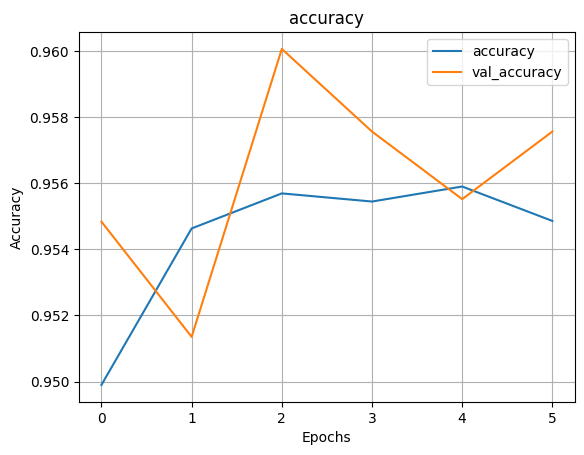

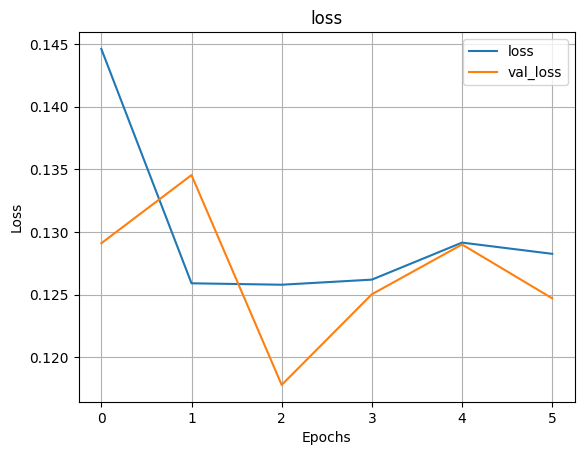

In [8]:
# Print best model config
print("\n🏆 Best Model Configuration:")
for k, v in best_config.items():
    print(f"{k}: {v}")

# Save best model
best_model.save('best_mlp_model.h5')
print("\n📁 Best model saved as 'best_mlp_model.h5'")

# Combine and save all scores
all_results_df = pd.concat(all_scores)
all_results_df.to_csv("mlp_model_results.csv", index=True)
print("Results saved to mlp_model_results.csv")

# Plot training history of the best model
print("\n📊 Training History of Best Model:")
plot_history(best_history)

In [9]:
# Filter only validation results
val_results = all_results_df[all_results_df.index.str.contains("val")]

# Sort by F1 Score in descending order
val_results_sorted = val_results.sort_values(by="F1 Score", ascending=False)

# Display the top results
print("🔝 Top Validation Results by F1 Score:")
display(val_results_sorted.head(10))

🔝 Top Validation Results by F1 Score:


,Accuracy,Precision,Recall,F1 Score,FPR,FNR
val [64]-50-p3-d0.001,0.960067,0.954344,0.969983,0.962100,0.050786,0.030017
val [64]-50-p5-d0.001,0.959991,0.960781,0.962732,0.961756,0.043009,0.037268
val [64]-50-p3-d0.0,0.959991,0.961316,0.962152,0.961734,0.042374,0.037848
val [64]-100-p3-d0.0,0.958854,0.958568,0.962877,0.960718,0.045548,0.037123
val [64]-50-p1-d0.0,0.958779,0.956978,0.964472,0.960711,0.047453,0.035528
val [64]-100-p3-d0.001,0.958551,0.957883,0.963022,0.960445,0.046342,0.036978
val [64]-100-p5-d0.0,0.958172,0.957588,0.962587,0.960081,0.046659,0.037413
val [64]-100-p1-d0.0,0.958097,0.958508,0.961427,0.959965,0.045548,0.038573
val [64]-50-p5-d0.0,0.957945,0.956121,0.963747,0.959919,0.048405,0.036253
val [64]-100-p1-d0.001,0.957945,0.958231,0.961427,0.959826,0.045866,0.038573
